# Import Everything 

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import xarray as xr
import math
from tkinter.filedialog import askopenfilename, askopenfilenames
from lmfit.models import GaussianModel
from scipy.optimize import curve_fit
from scipy.signal import find_peaks
import lmfit
from scipy.stats import norm
from scipy.interpolate import interp1d
from matplotlib.collections import LineCollection
from matplotlib.widgets import Slider, TextBox, CheckButtons, RangeSlider
%matplotlib widget

# allow multiple outputs in one cell
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = 'all'

def poly2(x, a, b, c):
    return a * x**2 + b * x + c


def poly4(x, a, b, c, d, e):
    return a * x**4 + b * x**3 + c * x**2 + d * x + e

def poly3(x, a, b, c, d):
    return a * x**3 + b * x**2 + c * x + d

def gaussian(x, a, x0, sigma):
    return a * np.exp(-(x - x0)**2 / (2 * sigma**2))

def gaussian_fwhm(sigma):
    fwhm = 2 * math.sqrt(2 * math.log(2)) * sigma
    return fwhm


def heatmap_interactive(_x, _y, _data, _title, _cmap='jet', _symlog=False, _linthresh=1.0):
    fig = plt.figure(figsize=(8, 8))
    gs = gridspec.GridSpec(2, 2, width_ratios=[1, 0.5], height_ratios=[0.5, 1], hspace=0.2, wspace=0.2)
    ax_main = plt.subplot(gs[1, 0])
    main_plot = ax_main.pcolormesh(_x, _y, _data, cmap=_cmap)
    ax_main.set(xlabel='Delay / ps', ylabel='Wavelength / nm')
    # set mixed log-lin scale with threshold value linthresh
    if _symlog:
        ax_main.set_xscale('symlog', linthresh=_linthresh)
    # set axis range to min and max values
    ax_main.set_xlim(_x[0],_x[-1])
    ax_main.set_ylim(_y[0],_y[-1]) 

    ax_kin = plt.subplot(gs[0, 0])
    line_kin, = ax_kin.plot(_x,np.zeros(_x.shape))
    kin_zero_line, = ax_kin.plot([_x[0],_x[-1]],[0,0], color="0.6")
    ax_kin.set_xlim(_x[0],_x[-1])
    if _symlog:
        ax_kin.set_xscale('symlog', linthresh=_linthresh)

    ax_spec = plt.subplot(gs[1, 1])
    line_spec, = ax_spec.plot(np.zeros(_y.shape),_y)
    spec_zero_line, = ax_spec.plot([0,0],[_y[0],_y[-1]], color="0.6")
    ax_spec.set_ylim(_y[0],_y[-1])        
    
    # This lower bounds list is necessary because the blocks in the 2D-plot cover a certain range
    def create_lower_bounds(_value_list):
        result = np.empty_like(_value_list)
        #first lower bound is equal to the lowest value in the nm-list
        result[0] = _value_list[0]
        #example: lower bound for 100 ps is 97.5 ps if the value prior is 95 ps, and 75 ps if the value prior is 50 ps.
        for i in range(1,len(_value_list)):
            result[i] = (_value_list[i]+_value_list[i-1])/2
        return result    
    
    nm_lower_bounds = create_lower_bounds(_y)
    time_lower_bounds = create_lower_bounds(_x)
    
    def nm_to_index(_nm):
        return np.where(_nm > nm_lower_bounds)[0][-1]
    
    def time_to_index(_time):
        return np.where(_time > time_lower_bounds)[0][-1]
    
    def mouse_move(event):
        x = event.xdata
        y = event.ydata
        if x is not None and y is not None:
            if x>=_x[0] and x<=_x[-1] and y>=_y[0] and y<=_y[-1]:
                # update spectra slice and rescale
                new_spec = _data[:,time_to_index(x)]
                line_spec.set_xdata(new_spec)
                spec_bounds = ax_spec.get_ylim()
                spec_range = new_spec[(_y>=spec_bounds[0]) & (_y<=spec_bounds[1])].max()-new_spec[(_y>=spec_bounds[0]) & (_y<=spec_bounds[1])].min()
                ax_spec.set_xlim(new_spec[(_y>=spec_bounds[0]) & (_y<=spec_bounds[1])].min()-0.1*spec_range,new_spec[(_y>=spec_bounds[0]) & (_y<=spec_bounds[1])].max()+0.1*spec_range)            

                # update kinetic slice and rescale
                new_kin = _data[nm_to_index(y),:]
                line_kin.set_ydata(new_kin)
                kin_bounds = ax_kin.get_xlim()  
                kin_range = new_kin[(_x>=kin_bounds[0]) & (_x<=kin_bounds[1])].max()-new_kin[(_x>=kin_bounds[0]) & (_x<=kin_bounds[1])].min()                
                ax_kin.set_ylim(new_kin[(_x>=kin_bounds[0]) & (_x<=kin_bounds[1])].min()-0.1*kin_range,new_kin[(_x>=kin_bounds[0]) & (_x<=kin_bounds[1])].max()+0.1*kin_range)
                
                # redraw figure
                fig.canvas.draw_idle()
             
    fig.canvas.mpl_connect('motion_notify_event', mouse_move) 
    
    # find max absolute value of 2D data in the specified zoom mode of the plot
    def get_maxvalue(_xlim, _ylim, _xvals, _yvals, _data_array):
        y_filter = (_yvals>=_ylim[0]) & (_yvals<=_ylim[1])
        x_filter = (_xvals>=_xlim[0]) & (_xvals<=_xlim[1])
        
        if not np.all(y_filter == False) and not np.all(x_filter == False):
            return np.amax(np.abs(_data_array[y_filter][:,x_filter]))
        else:
            return 0
    
    def on_xlims_change(event_ax):
        ax_kin.set_xlim(event_ax.get_xlim())
        
        new_max = get_maxvalue(event_ax.get_xlim(),event_ax.get_ylim(),_x,_y,_data)
        if new_max > 0:
            main_plot.set_clim(vmin=-new_max, vmax=new_max)

    def on_ylims_change(event_ax):
        ax_spec.set_ylim(event_ax.get_ylim())
        
        new_max = get_maxvalue(event_ax.get_xlim(),event_ax.get_ylim(),_x,_y,_data)
        if new_max > 0:
            main_plot.set_clim(vmin=-new_max, vmax=new_max)        

    ax_main.callbacks.connect('xlim_changed', on_xlims_change)
    ax_main.callbacks.connect('ylim_changed', on_ylims_change)
   
    plt.show(block=False)

def heatmap_interactive_slide(_wl, _delays, _data, _title, _cmap='jet', _symlog=False, _linthresh=1.0):
    global is_dragging
    is_dragging = False
    global kin_autoscale
    global spec_autoscale
    kin_autoscale = True
    spec_autoscale = True

    fig_width = 13
    fig_height = 10

    fig = plt.figure(figsize=(fig_width, fig_height))
    gs = gridspec.GridSpec(ncols=2, nrows=2, bottom=0.2, top=0.9, width_ratios=[1, 1], height_ratios=[1, 1], hspace=0.5, wspace=0.3)
    
    # Set up 2D map of data
    ax_main = plt.subplot(gs[0, 0])
    main_plot = ax_main.pcolormesh(_wl, _delays, _data, cmap=_cmap)
    ax_main.set(xlabel='Wavelength / nm', ylabel='Delay / ps')
    # set mixed log-lin scale with threshold value linthresh
    if _symlog:
        ax_main.set_yscale('symlog', linthresh=_linthresh)
    # set axis range to min and max values
    ax_main.set_xlim(_wl[0],_wl[-1])
    ax_main.set_ylim(_delays[0],_delays[-1]) 

    ax_main_pos = ax_main.get_position()

    ax_spec = plt.subplot(gs[1, 0])
    line_spec, = ax_spec.plot(_wl,np.zeros(_wl.shape))
    spec_zero_line, = ax_spec.plot([_wl[0],_wl[-1]],[0,0], color="0.6")
    ax_spec.set_xlim(_wl[0],_wl[-1])
    ax_spec.set_title('Spectrum at 0 ps')
    ax_spec.set_xlabel('Wavelength / nm')
    ax_spec.set_ylabel(r'$\Delta$OD')               
    ax_spec.autoscale(enable=False)

    ax_spec_pos = ax_spec.get_position()

    ax_kin = plt.subplot(gs[0, 1])
    line_kin, = ax_kin.plot(_delays,np.zeros(_delays.shape))
    kin_zero_line, = ax_kin.plot([_delays[0],_delays[-1]],[0,0], color="0.6")
    ax_kin.set_xlim(_delays[0],_delays[-1])        
    ax_kin.set_title('Kinetics at 0 nm')
    ax_kin.set_xlabel('Delay / ps')
    ax_kin.set_ylabel(r'$\Delta$OD')
    ax_kin.autoscale(enable=False)
    if _symlog:
        ax_kin.set_xscale('symlog', linthresh=_linthresh)                 

    ax_kin_pos = ax_kin.get_position()
    
    # This lower bounds list is necessary because the blocks in the 2D-plot cover a certain range
    def create_lower_bounds(_value_list):
        result = np.empty_like(_value_list)
        #first lower bound is equal to the lowest value in the nm-list
        result[0] = _value_list[0]
        #example: lower bound for 100 ps is 97.5 ps if the value prior is 95 ps, and 75 ps if the value prior is 50 ps.
        for i in range(1,len(_value_list)):
            result[i] = (_value_list[i] + _value_list[i-1])/2
        return result    
    
    nm_lower_bounds = create_lower_bounds(_wl)
    time_lower_bounds = create_lower_bounds(_delays)
    
    def nm_to_index(_nm):
        return np.where(_nm >= nm_lower_bounds)[0][-1]
    
    def time_to_index(_time):
        return np.where(_time >= time_lower_bounds)[0][-1]
    
    def clear_lines(ax):
        for child in ax.get_children():
            if isinstance(child, LineCollection):
                child.remove()
    
    def update_selection(x,y):
        wl_index = nm_to_index(x)
        time_index = time_to_index(y)

        spec_old_ylim = ax_spec.get_ylim()
        # update spectra slice and rescale
        new_spec = _data[time_index,:]
        line_spec.set_ydata(new_spec)
        spec_bounds = ax_spec.get_xlim()
        new_spec_visible = new_spec[(_wl>=spec_bounds[0]) & (_wl<=spec_bounds[1])]
        spec_range = new_spec_visible.max() - new_spec_visible.min()                
        if not is_checked(spec_checkbox):
            ax_spec.set_ylim(spec_old_ylim)
        else:
            ax_spec.set_ylim(new_spec_visible.min() - 0.1*spec_range, new_spec_visible.max() + 0.1*spec_range)        
        
        ax_spec.set_title(f'Spectrum at {_delays[time_index]} ps')        
        clear_lines(ax_spec)
        ax_spec.vlines([_wl[wl_index]], ymin=[ax_spec.get_ylim()[0]], ymax=[ax_spec.get_ylim()[1]], colors=['black'])

        kin_old_ylim = ax_kin.get_ylim()
        # update kinetic slice and rescale
        new_kin = _data[:,wl_index]
        line_kin.set_ydata(new_kin)
        kin_bounds = ax_kin.get_xlim()  
        new_kin_visible = new_kin[(_delays>=kin_bounds[0]) & (_delays<=kin_bounds[1])]
        kin_range = new_kin_visible.max() - new_kin_visible.min()
        if not is_checked(kin_checkbox):
            ax_kin.set_ylim(kin_old_ylim)
        else:
            ax_kin.set_ylim(new_kin_visible.min() - 0.1*kin_range, new_kin_visible.max() + 0.1*kin_range)  
        
        ax_kin.set_title(f'Kinetics at {_wl[wl_index]:.0f} nm')      
        clear_lines(ax_kin)
        ax_kin.vlines([_delays[time_index]], ymin=[ax_kin.get_ylim()[0]], ymax=[ax_kin.get_ylim()[1]], colors=['black'])
        
        clear_lines(ax_main)
        ax_main.hlines([_delays[time_index]], xmin=[ax_main.get_xlim()[0]], xmax=[ax_main.get_xlim()[1]], colors=['white'])
        ax_main.vlines([_wl[wl_index]], ymin=[ax_main.get_ylim()[0]], ymax=[ax_main.get_ylim()[1]], colors=['white'])

        # redraw figure
        fig.canvas.draw_idle()

        return _wl[wl_index], _delays[time_index]

    def mouse_click(event):
        global is_dragging        
        x = event.xdata
        y = event.ydata
        if event.inaxes == ax_main:
            is_dragging = True
            new_wl, new_delay = update_selection(event.xdata,event.ydata)
            slider_wl.set_val(new_wl)
            slider_delay.set_val(new_delay)

    def mouse_move(event):
        x = event.xdata
        y = event.ydata
        
        if event.inaxes == ax_main and is_dragging:
            new_wl, new_delay = update_selection(event.xdata,event.ydata)
            slider_wl.set_val(new_wl)
            slider_delay.set_val(new_delay)            

    def mouse_release(event):
        global is_dragging
        is_dragging = False
             
    fig.canvas.mpl_connect('button_press_event', mouse_click)
    fig.canvas.mpl_connect('motion_notify_event', mouse_move)
    fig.canvas.mpl_connect('button_release_event', mouse_release)


    # Create sliders
    slider_thickness = 0.05
    slider_wl_width = ax_main_pos.x1 - ax_main_pos.x0
    slider_delay_height = ax_main_pos.y1 - ax_main_pos.y0

    ax_slider_wl = fig.add_axes(rect=(ax_main_pos.x0, ax_main_pos.y1, slider_wl_width, slider_thickness))
    ax_slider_delay = fig.add_axes(rect=(ax_main_pos.x1, ax_main_pos.y0, slider_thickness/fig_width*fig_height, slider_delay_height))

    slider_wl = Slider(ax_slider_wl, '', _wl[0], _wl[-1], valinit=_wl[0], valstep=_wl)
    slider_delay = Slider(ax_slider_delay, '', _delays[0],_delays[-1], valinit=_delays[0], orientation='vertical', valstep=_delays) 

    # Function to update the plot based on slider values
    def update_by_slider(val):
        wl_val = slider_wl.val
        delay_val = slider_delay.val
        update_selection(wl_val, delay_val)

    # Connect the sliders to the update function
    slider_wl.on_changed(update_by_slider)
    slider_delay.on_changed(update_by_slider)


    # Colormap slider
    ax_slider_cmap = fig.add_axes(rect=(ax_main_pos.x0 - 0.09, ax_main_pos.y0, slider_thickness/fig_width*fig_height, slider_delay_height))
    slider_cmap = RangeSlider(ax_slider_cmap, 'Z scale', _data.min(), _data.max(), valinit=(_data.min(), _data.max()), orientation='vertical')     

    # Update function for the range slider
    def update_cmap(val):
        min_val, max_val = slider_cmap.val
        main_plot.set_clim(vmin=min_val, vmax=max_val)  # Update the color limits
        fig.canvas.draw_idle()  # Redraw the figure

    # Connect the range slider to the update function
    slider_cmap.on_changed(update_cmap)
    # find max absolute value of 2D data in the specified zoom mode of the plot
    def get_maxvalue(_xlim, _ylim, _xvals, _yvals, _data_array):
        y_filter = (_yvals>=_ylim[0]) & (_yvals<=_ylim[1])
        x_filter = (_xvals>=_xlim[0]) & (_xvals<=_xlim[1])
        
        if not np.all(y_filter == False) and not np.all(x_filter == False):
            return np.amax(np.abs(_data_array[y_filter][:,x_filter]))
        else:
            return 0
    
    def on_xlims_change(event_ax):
        ax_spec.set_xlim(event_ax.get_xlim())
        
        new_max = get_maxvalue(event_ax.get_xlim(),event_ax.get_ylim(),_wl,_delays,_data)
        if new_max > 0:
            main_plot.set_clim(vmin=-new_max, vmax=new_max)

    def on_ylims_change(event_ax):
        ax_kin.set_xlim(event_ax.get_ylim())
        
        new_max = get_maxvalue(event_ax.get_xlim(),event_ax.get_ylim(),_wl,_delays,_data)
        if new_max > 0:
            main_plot.set_clim(vmin=-new_max, vmax=new_max)        

    ax_main.callbacks.connect('xlim_changed', on_xlims_change)
    ax_main.callbacks.connect('ylim_changed', on_ylims_change)

    # Limit textsboxes for kinetics and spectra

    def update_from_text(text, text_box):
        global kin_autoscale
        global spec_autoscale
        # kin_checkbox.set_active(0, False)
        try:
            if (text_box == text_kin_min) or (text_box == text_kin_max):
                ax_kin.set_ylim(float(text_kin_min.text), float(text_kin_max.text))
                kin_checkbox.set_active(0, False)
            elif (text_box == text_spec_min) or (text_box == text_spec_max):
                ax_spec.set_ylim(float(text_spec_min.text), float(text_spec_max.text))
                spec_checkbox.set_active(0, False)
                print(spec_checkbox.get_status())
            fig.canvas.draw_idle()
        except ValueError:
            pass  # Ignore invalid input

    def is_checked(checkbox):
        return checkbox.get_status()[0]

    ax_text_kin_min = plt.axes([ax_kin_pos.x0 + 0.05, ax_kin_pos.y0 - 0.09, 0.05, 0.03])
    ax_text_kin_max = plt.axes([ax_kin_pos.x0 + 0.16, ax_kin_pos.y0 - 0.09, 0.05, 0.03])

    ax_text_spec_min = plt.axes([ax_spec_pos.x0 + 0.05, ax_spec_pos.y0 - 0.09, 0.05, 0.03])
    ax_text_spec_max = plt.axes([ax_spec_pos.x0 + 0.16, ax_spec_pos.y0 - 0.09, 0.05, 0.03])

    text_kin_min = TextBox(ax_text_kin_min, r'$\Delta$OD min', initial=str(0))
    text_kin_max = TextBox(ax_text_kin_max, r'$\Delta$OD max', initial=str(0))

    text_spec_min = TextBox(ax_text_spec_min, r'$\Delta$OD min', initial=str(0))
    text_spec_max = TextBox(ax_text_spec_max, r'$\Delta$OD max', initial=str(0))

    text_kin_min.on_submit(lambda text: update_from_text(text, text_kin_min))
    text_kin_max.on_submit(lambda text: update_from_text(text, text_kin_max))
    text_spec_min.on_submit(lambda text: update_from_text(text, text_spec_min))
    text_spec_max.on_submit(lambda text: update_from_text(text, text_spec_max))
   
    ax_kin_checkbox = plt.axes([ax_kin_pos.x0 + 0.22, ax_kin_pos.y0 - 0.09, 0.12, 0.03])
    ax_spec_checkbox = plt.axes([ax_spec_pos.x0 + 0.22, ax_spec_pos.y0 - 0.09, 0.12, 0.03])

    kin_checkbox = CheckButtons(ax_kin_checkbox, ['Autoscale kin.'], [True])
    spec_checkbox = CheckButtons(ax_spec_checkbox, ['Autoscale spec.'], [True])

    plt.show(block=False)



def lin(x,a,b):
    return a*x+b


def smooth_data_average_window(data, window_size):
    # Calculate rolling mean with specified window size
    windows = data.rolling(spectral= window_size ,center = True, min_periods=1)
    moving_average = windows.mean()
    return moving_average

def calculate_fwhm(spectral_data, time_coords):
    #spectral_data = np.abs(spectral_data)
    peak_value = np.max(spectral_data)
    half_max = peak_value / 2.0
    indices_above_half = np.where(spectral_data >= half_max)[0]
    
    if len(indices_above_half) < 2:
        return np.nan  # Not enough data to calculate FWHM
    
    max_value = np.where(spectral_data == peak_value )[0]
    valid_indices = [max_value[0]] #Create an where where we gonna remove the data that are above the half but that don't correspond to the peak
    current_value = max_value[0]
    for i in  np.where(indices_above_half > max_value)[0]: #Look in the positive increment  
        if indices_above_half[i] == current_value + 1:
            valid_indices.append(indices_above_half[i])
            current_value += 1
        else:
            break
    current_value = max_value[0]
    for i in  reversed(np.where(indices_above_half < max_value)[0]): #Look in the negative increment  
        if indices_above_half[i] == current_value - 1:
            valid_indices.insert(0,indices_above_half[i])
            current_value -= 1
        else:
            break

    # Interpolate to get a more accurate crossing point
    f_left = interp1d(spectral_data[valid_indices[0]-1:valid_indices[0]+1], time_coords[valid_indices[0]-1:valid_indices[0]+1], kind='linear')
    f_right = interp1d(spectral_data[valid_indices[-1]:valid_indices[-1]+2], time_coords[valid_indices[-1]:valid_indices[-1]+2], kind='linear')
    left_half_max_time = f_left(half_max)
    right_half_max_time = f_right(half_max)
    
    # Calculate FWHM as the difference between these two time points
    fwhm = right_half_max_time - left_half_max_time

    return fwhm 


def heatmap_interactive_FFT(_x, _y, _data, _title, _cmap='jet', _symlog=False):
    # Create a figure with specified size
    fig = plt.figure(figsize=(8, 8))

    a1_modes = [99, 193, 410, 440, 502, 707, 784]  # red (a1 symmetry)
    b1_modes = [18, 94, 140, 191, 260, 282, 454, 603, 660]  # blue (b1 symmetry)


    # Define a grid layout for the subplots
    gs = gridspec.GridSpec(2, 2, width_ratios=[1, 0.5], height_ratios=[0.5, 1], hspace=0.2, wspace=0.2)

    # Create the main plot in the bottom-left corner of the grid
    ax_main = plt.subplot(gs[1, 0])
    main_plot = ax_main.pcolormesh(_x, _y, _data, cmap=_cmap)
    ax_main.set(xlabel='Wavenumber /cm-1', ylabel='FFT intensity')
    # Set mixed log-lin scale with threshold value linthresh if symlog is True
    if _symlog:
        ax_main.set_xscale('symlog', linthresh=0.01)
    # Set axis range to min and max values
    ax_main.set_xlim(_x[0],_x[-1])
    ax_main.set_ylim(_y[0],_y[-1])



    # Create the kinetic plot in the top-left corner of the grid
    ax_kin = plt.subplot(gs[0, 0])
    line_kin, = ax_kin.plot(_x,np.zeros(_x.shape))
    kin_zero_line, = ax_kin.plot([_x[0],_x[-1]],[0,0], color="0.6")
    ax_kin.set_xlim(_x[0],_x[-1])
    if _symlog:
        ax_kin.set_xscale('symlog', linthresh=0.01)
        # Overlay a1 modes
    for freq in a1_modes:
        ax_kin.axvline(freq, color='red', linestyle='-', ymax=0.2)  # vertical red line
        ax_kin.text(freq, 0.22, f'{freq}', color='red', ha='center', va='bottom', fontsize=8)

# Overlay b1 modes
    for freq in b1_modes:
        ax_kin.axvline(freq, color='blue', linestyle='-', ymax=0.2)
        ax_kin.text(freq, 0.22, f'{freq}', color='blue', ha='center', va='bottom', fontsize=8)


    # Create the spectrum plot in the bottom-right corner of the grid
    ax_spec = plt.subplot(gs[1, 1])
    line_spec, = ax_spec.plot(np.zeros(_y.shape),_y)
    spec_zero_line, = ax_spec.plot([0,0],[_y[0],_y[-1]], color="0.6")
    ax_spec.set_ylim(_y[0],_y[-1])

    # This lower bounds list is necessary because the blocks in the 2D-plot cover a certain range
    def create_lower_bounds(_value_list):
        result = np.empty_like(_value_list)
        # First lower bound is equal to the lowest value in the nm-list
        result[0] = _value_list[0]
        # Example: lower bound for 100 ps is 97.5 ps if the value prior is 95 ps, and 75 ps if the value prior is 50 ps.
        for i in range(1,len(_value_list)):
            result[i] = (_value_list[i]+_value_list[i-1])/2
        return result

    nm_lower_bounds = create_lower_bounds(_y)
    time_lower_bounds = create_lower_bounds(_x)

    def nm_to_index(_nm):
        return np.where(_nm > nm_lower_bounds)[0][-1]

    def time_to_index(_time):
        return np.where(_time > time_lower_bounds)[0][-1]

    def mouse_move(event):
        x = event.xdata
        y = event.ydata
        if x is not None and y is not None:
            if x>=_x[0] and x<=_x[-1] and y>=_y[0] and y<=_y[-1]:

                # Update spectra slice and rescale
                new_spec = _data[:,time_to_index(x)]
                line_spec.set_xdata(new_spec)
                spec_bounds = ax_spec.get_ylim()
                spec_range = new_spec[(_y>=spec_bounds[0]) & (_y<=spec_bounds[1])].max()-new_spec[(_y>=spec_bounds[0]) & (_y<=spec_bounds[1])].min()
                ax_spec.set_xlim(new_spec[(_y>=spec_bounds[0]) & (_y<=spec_bounds[1])].min()-0.1*spec_range,new_spec[(_y>=spec_bounds[0]) & (_y<=spec_bounds[1])].max()+0.1*spec_range)

                # Update kinetic slice and rescale
                new_kin = _data[nm_to_index(y),:]
                line_kin.set_ydata(new_kin)
                kin_bounds = ax_kin.get_xlim()
                kin_range = new_kin[(_x>=kin_bounds[0]) & (_x<=kin_bounds[1])].max()-new_kin[(_x>=kin_bounds[0]) & (_x<=kin_bounds[1])].min()
                ax_kin.set_ylim(new_kin[(_x>=kin_bounds[0]) & (_x<=kin_bounds[1])].min()-0.1*kin_range,new_kin[(_x>=kin_bounds[0]) & (_x<=kin_bounds[1])].max()+0.1*kin_range)

                # Redraw figure
                fig.canvas.draw_idle()

    # Connect mouse move event to the figure
    fig.canvas.mpl_connect('motion_notify_event', mouse_move)

    # Find max absolute value of 2D data in the specified zoom mode of the plot
    def get_maxvalue(_xlim, _ylim, _xvals, _yvals, _data_array):
        y_filter = (_yvals>=_ylim[0]) & (_yvals<=_ylim[1])
        x_filter = (_xvals>=_xlim[0]) & (_xvals<=_xlim[1])

        if not np.all(y_filter == False) and not np.all(x_filter == False):
            return np.amax(np.abs(_data_array[y_filter][:,x_filter]))
        else:
            return 0

    def on_xlims_change(event_ax):
        ax_kin.set_xlim(event_ax.get_xlim())

        new_max = get_maxvalue(event_ax.get_xlim(),event_ax.get_ylim(),_x,_y,_data)
        if new_max > 0:
            main_plot.set_clim(vmin=-new_max, vmax=new_max)

    def on_ylims_change(event_ax):
        ax_spec.set_ylim(event_ax.get_ylim())

        new_max = get_maxvalue(event_ax.get_xlim(),event_ax.get_ylim(),_x,_y,_data)
        if new_max > 0:
            main_plot.set_clim(vmin=-new_max, vmax=new_max)

    # Connect axis limits change events to the respective functions
    ax_main.callbacks.connect('xlim_changed', on_xlims_change)
    ax_main.callbacks.connect('ylim_changed', on_ylims_change)

    # Show the plot
    plt.show(block=False)



# Calibration

In [ ]:
#Wavelength Calibaration
pixels = np.arange(0, 2048)
pixels_calibation = [583,685,1274,1490]
wv_calibation = [447,469,605,655]

calibration,_ = curve_fit(lin,pixels_calibation,wv_calibation, method= "dogbox")
Fit_calibration = lin(pixels,*calibration)

plt.figure()
plt.plot(pixels_calibation,wv_calibation,  'o', label='Data')
plt.plot(pixels,Fit_calibration, '-', label='Fit')
plt.xlabel('Pixels)')
plt.ylabel('Wavelength (nm)')
plt.legend()
plt.grid("On")
plt.show()
print(f"y = {calibration[0]}x + {calibration[1]}")

lambda_values = calibration[0] * pixels + calibration[1]
#lambda_values = pixels

# Step 1: Import the Solvent scan

In [ ]:
time_file = askopenfilename(filetypes=[("Text files", "*.txt")], title="Select Time vector data")
time_solvent = np.loadtxt(time_file)
time_solvent = time_solvent / 1000  # convert from fs to ps

# Get TA scan files
ta_scan_files = askopenfilenames(filetypes=[("Text files", "*.txt")], title="Select solvent scan file(s)")

if len(ta_scan_files) > 1:
    Full_Data = np.zeros((2048, len(time_solvent), len(ta_scan_files))) #Array that will contain all the 
    for n, file in enumerate(ta_scan_files):
        data = np.loadtxt(file)
        Full_Data[:, :, n] = data  # save data array to 3D array (lambda, time, scan)
    
    scan_solvent = np.mean(Full_Data, axis=2)
    scan_solvent = scan_solvent - np.mean(scan_solvent[:,1:5],axis=1)[:, np.newaxis] #Baseline correction 
else:
    scan_solvent = np.loadtxt(ta_scan_files[0])
# Now 'scan' contains the processed data

#Create an xarray to manipulate the data (much easier)
dataset_solvent = xr.Dataset(
    {
        "data": (["time","spectral",], np.transpose(scan_solvent))
    },
    coords={
        "time": time_solvent,
        "spectral": lambda_values
    }
)

# Print the dataset
print(dataset_solvent)

heatmap_interactive(dataset_solvent.time, dataset_solvent.spectral, dataset_solvent['data'].transpose('spectral','time'),'Averaged scan plot',_symlog=False)

In [ ]:
heatmap_interactive_slide(dataset_solvent.spectral.values, dataset_solvent.time.values, dataset_solvent['data'],'Averaged uncorrected scan plot',_symlog=False)

In [ ]:
heatmap_interactive_slide(dataset_BetaC.spectral.values, dataset_BetaC.time.values, dataset_BetaC['data'],'Averaged uncorrected scan plot',_symlog=False)

In [ ]:
dataset_solvent.to_netcdf('/Users/vard/Library/CloudStorage/OneDrive-MassachusettsInstituteofTechnology/New Cu/Data nc format/cuvette.nc')

In [ ]:
dataset_cuvette= xr.open_dataset('/Users/vard/Library/CloudStorage/OneDrive-MassachusettsInstituteofTechnology/New Cu/Data nc format/cuvette.nc')

# Step 2 - Get IRF information from it  

In [ ]:
lower_signal_bound = 430
higher_singal_bound = 565
threshold = 0.0035

wl_range = np.arange(lower_signal_bound,higher_singal_bound+1,1)



ROI = smooth_data_average_window(dataset_solvent.sel(spectral=slice(lower_signal_bound, higher_singal_bound)),35)

ROI_FWHM_values = []
gaussian_fit_param = np.zeros([np.shape(wl_range)[0],3])
i = 0


for spectral_value in wl_range: 
    # Extract the kinetic trace for the selected spectral value
    kinetic_trace = np.abs(ROI['data'].sel(spectral=spectral_value, method='nearest'))

    # Find peaks in the kinetic trace
    peaks, _ = find_peaks(kinetic_trace)
    filtered_peaks = peaks[kinetic_trace[peaks] > threshold]

    # Ensure we have at least two peaks
    if len(filtered_peaks) >= 2:
        # Identify the two outermost peaks
        first_peak = filtered_peaks[0]
        last_peak = filtered_peaks[-1]
    # Create a mask where values between the two outermost peaks are removed
        mask = np.ones_like(kinetic_trace, dtype=bool)  
        mask[first_peak:last_peak+1] = False  
        
        # Apply the mask to the data
        sliced_kinetics = kinetic_trace.where(mask) 

        # Fit a Gaussian to the sliced data
        time_data = time_data = np.concatenate([sliced_kinetics.time[0:first_peak].values, sliced_kinetics.time[last_peak+1:].values], axis=0)
        kinetic_data = sliced_kinetics.data[~np.isnan(sliced_kinetics.data)] #Remove the NaN values, needed for the fit 

        # Define Gaussian model
        gauss_model = GaussianModel()

        # Set initial parameters
        gap_center = (sliced_kinetics.time[first_peak].values + sliced_kinetics.time[last_peak].values) / 2
        params = gauss_model.make_params(amplitude=ROI['data'].max().item(), center=gap_center, sigma=np.std(time_data))

        # Fit the model to the data
        fit_result = gauss_model.fit(kinetic_data, params, x=time_data) 

        # Generate smooth fitted curve
        smooth_time = np.linspace(time_data.min(), time_data.max(), 300)
        fitted_curve = gauss_model.eval(fit_result.params, x=smooth_time)

        #Print fitted parameters
        fitted_params = fit_result.params
        gaussian_fit_param[i][0] = fitted_params['amplitude'].value
        gaussian_fit_param[i][1] = fitted_params['center'].value
        gaussian_fit_param[i][2] = fitted_params['sigma'].value
        ROI_FWHM_values.append(gaussian_fwhm(fitted_params['sigma'].value*1000))
        i = i+1
    else:
        fwhm = calculate_fwhm(kinetic_trace, kinetic_trace.time.values)*1000 
        ROI_FWHM_values.append(fwhm)
        i = i+1

fwhm_trend_solvent,_ = curve_fit(lin,wl_range,ROI_FWHM_values, method= "dogbox")
fwhm_lin_solvent = lin(wl_range,*fwhm_trend_solvent)
plt.figure(figsize=(12, 6))
plt.scatter(wl_range,ROI_FWHM_values,color='blue', marker='x')
plt.plot(wl_range,fwhm_lin_solvent, '--', label='Linear Fit') 
plt.legend()
plt.ylim([0,400])
plt.title('IRF estimation with a Gaussian Fit')
plt.grid('On')
plt.xlabel("Wavelength (nm)")
plt.ylabel("FWHM (fs)")




In [ ]:
def poly2(x, a, b, c):
    return a * x**2 + b * x + c


def poly4(x, a, b, c, d, e):
    return a * x**4 + b * x**3 + c * x**2 + d * x + e

def poly3(x, a, b, c, d):
    return a * x**3 + b * x**2 + c * x + d

params_position_IRF_solvent, _ = curve_fit(poly4, wl_range, gaussian_fit_param[:,1])
Fit_coherence_solvent = poly4(wl_range,*params_position_IRF_solvent)


plt.figure(figsize=(12, 6))
plt.scatter(gaussian_fit_param[:,1],wl_range,color='blue', marker='x')
plt.plot(Fit_coherence_solvent,wl_range,  '-', label='Fit', color = 'red')
plt.title('IRF estimation with a Gaussian Fit')
plt.grid('On')
plt.ylabel("Wavelength (nm)")
plt.xlabel("position CA - ps")

# Step 3 - Get CA paramters 

### Single position - Use it to manually determine goood parameters for the lowest region of your fit (eg . 469)

In [ ]:
def Fcos(params, time): 
    B = params['B']
    Phi = params['Phi']
    A0 = params['A0']
    A1 = params['A1']
    tau = params['CA_FWHM']
    dt0 = params['CA_center']
    
    cos_term = np.cos(B * (time - dt0)**2 + Phi) 
    exp_term = A0 * np.exp(-4 * np.log(2) * ((time - dt0) ** 2) / (tau ** 2))
    correction_term = A1 * (8 * np.log(2) / (tau ** 2)) * (time - dt0) * np.exp(-4 * np.log(2) * ((time - dt0) ** 2) / (tau ** 2))
    
    result = cos_term * (exp_term - correction_term)
    
    return result


def Fcos_c(params, time): 

    H = lambda x: np.heaviside(x, 1)

    B = params['B']
    Phi = params['Phi']
    A0 = params['A0']
    A1 = params['A1']
    tau = params['CA_FWHM']
    dt0 = params['CA_center']
    const = params['const']
    dts = params['Signal_center']
    
    cos_term = np.cos(B * (time - dt0)**2 + Phi) 
    exp_term = A0 * np.exp(-4 * np.log(2) * ((time - dt0) ** 2) / (tau ** 2))
    correction_term = A1 * (8 * np.log(2) / (tau ** 2)) * (time - dt0) * np.exp(-4 * np.log(2) * ((time - dt0) ** 2) / (tau ** 2))
    
    result = cos_term * (exp_term - correction_term)+ const*H(time - dts)
    
    return result

def Gaussian(params,t):
    c = params['c']
    sigma = params['sigma']
    gauss = (1 / (sigma * np.sqrt(2 * np.pi))) * np.exp(-((t - c) ** 2) / (2 * sigma ** 2))
    gauss_first_derivative = ((c - t) / (sigma ** 3 * np.sqrt(2 * np.pi))) * np.exp(-((t - c) ** 2) / (2 * sigma ** 2))
    gauss_second_derivative = ((t ** 2 - 2 * c * t - sigma ** 2 + c ** 2) / (sigma ** 5 * np.sqrt(2 * np.pi))) * np.exp(-((t - c) ** 2) / (2 * sigma ** 2))
    return gauss + gauss_first_derivative + gauss_second_derivative



def residuals_Fcos(params, time, data):
    model = Fcos(params, time)
    return np.sqrt((model - data)**2)


def residuals_Fcos_c(params, time, data):
    model = Fcos_c(params, time)
    return np.sqrt((model - data)**2)

def residuals_gauss(params, t, data):
    model = Gaussian(params, t)
    return model - data

In [ ]:
wv_1 = 469 #in nm

xml_region = dataset_solvent.data.sel(spectral=slice(430, 560)).sel(time=slice(-1,2))
single_trace = xml_region.sel(spectral = [wv_1], method="nearest")
max_time = single_trace['time'][single_trace.argmax().item()].item()
single_trace = single_trace.sel(time = slice(max_time-0.5,max_time+0.5)) #Looks at -500 and +500 fs around the CA peak 
time = single_trace.time.values
data = single_trace.values.reshape(np.shape(single_trace.data)[0])

# Set up lmfit parameters
params = lmfit.Parameters()
params.add('B', value=  200.246245 , min = 0,vary = True) #determines how quickly the fringe periodicity increases 
params.add('Phi', value=155.508536   ,vary = True) #phase shift of the modulation 
params.add('A0', value=  -0.06680426     , vary = True) #Amplitude main Gaussian. Positve results in main peak down 
params.add('A1', value=5.3965e-04, vary = True) # help fit of asymmetric artifacts 
params.add('CA_FWHM', value= lin(469,*fwhm_trend)/1000,min=0, vary = True) #FWHM 
params.add('CA_center', value=  poly4(469,*params_position_IRF), vary = True) #Center of the chirp 


minimizer = lmfit.Minimizer(residuals_Fcos, params, fcn_args=(time, data))
result_init = minimizer.minimize()

x_lims = [max_time-0.2,max_time+0.3]
fig, (ax, ax2) = plt.subplots(nrows=2, gridspec_kw={'height_ratios': [3, 1]}, figsize=(12, 8))
ax.scatter(time, data, color='grey', s=25, label='Coherent Artifact', alpha=0.5)
ax.plot(time, Fcos(result_init.params, time), color='blue', linewidth=3, label='Modeling of the Artifact')
ax.set_xlim(x_lims)


residuals = data - Fcos(result_init.params, time)
ax2.plot(time, residuals, color='grey', label='Residual', alpha=0.5)

ax.set_xlabel("Time (ps)",fontsize=20)
ax.set_ylabel("ΔA",fontsize=20)
ax2.set_xlabel("Time (ps)",fontsize=20)
ax2.set_ylabel("Residual",fontsize=20)  
ax2.axhline(0, color='black', linewidth=0.5, linestyle='--')
ax2.set_xlim(ax.get_xlim()) 
ax2.set_ylim(ax.get_ylim()) 
ax.tick_params(axis='both', which='major', labelsize=15)
ax2.tick_params(axis='both', which='major', labelsize=15)

handles, labels = ax.get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()

ax.legend(handles,labels, loc='upper right',fontsize = 20)
ax2.legend(handles2, labels2, loc='upper right',fontsize = 20)
fig.suptitle(f"Modeling Coherent Artifact, solvent scan, {wv_1} nm",fontsize=25)
plt.tight_layout()



# Print the fit report
print(lmfit.fit_report(result_init))

# Use the previouly determine parameters to Fit the full region

In [ ]:
lower_end = wv_1
higher_end = 560

xml_region = dataset_solvent.data.sel(spectral=slice(lower_end, 560)).sel(time=slice(-1,2))

fit_CA_param = {}
fit_CA_result = np.transpose(np.zeros_like(xml_region))

for i, wavelength in enumerate(xml_region.spectral):
    single_trace = xml_region.sel(spectral=[wavelength], method="nearest")
    time = single_trace.time.values
    data = single_trace.values.reshape(np.shape(single_trace.data)[0])

    if i == 0:
        # Set up lmfit parameters for the first wavelength

        params = lmfit.Parameters()
        params.add('B', value= result_init.params['B'].value , min = 0,vary = False) #determines how quickly the fringe periodicity increases 
        params.add('Phi', value=result_init.params['Phi'].value  ,vary = False) #phase shift of the modulation 
        params.add('A0', value=  result_init.params['A0'].value     , vary = False) #Amplitude main Gaussian. Positve results in main peak down 
        params.add('A1', value=result_init.params['A1'].value, vary = False) # help fit of asymmetric artifacts 
        params.add('CA_FWHM', value= result_init.params['CA_FWHM'].value,min=0, vary = False) #FWHM 
        params.add('CA_center', value= result_init.params['CA_center'].value, vary = False) #Center of the chirp 
    else:
        # Use the previous wavelength's fitted parameters as initial values
        prev_wavelength = xml_region.spectral[i - 1].item()
        prev_params = fit_CA_param[prev_wavelength]
        params = lmfit.Parameters()
        for name, param in prev_params.items():
            params.add(name, value=param.value, vary=True) #, min=param.value*0.5, max=param.value*1.5

    # Perform minimization
    minimizer = lmfit.Minimizer(residuals_Fcos, params, fcn_args=(time, data))
    result = minimizer.minimize()

    # Store the fit result in the dictionary to be used for the next wavelength
    fit_CA_param[wavelength.item()] = result.params
    fit_CA_result[i] = Fcos(result.params, time)


In [ ]:
dataset_fit_CA = xr.Dataset(
    {
        "data": (["time","spectral",], np.transpose(fit_CA_result))
    },
    coords={
        "time": xml_region.time,
        "spectral": xml_region.spectral
    }
)

# Plot visualization

In [ ]:
xml_region = dataset_solvent.data.sel(spectral=slice(lower_end, higher_end)).sel(time=slice(-1,2))
# Assuming dataset_fit and dataset_fit2 are already defined
fig, axes = plt.subplots(2, 2, figsize=(12, 8))  # 1 row, 2 columns

# Plot the first dataset
dataset_fit_CA['data'].plot.imshow(ax=axes[0, 0])
axes[0, 0].set_title("Fit",fontsize=25)
axes[0, 0].set_aspect("auto")  # Set aspect ratio
axes[0, 0].set_xlabel("Time (ps)",fontsize=20)
axes[0, 0].set_ylabel("∆A",fontsize=20)
axes[0, 0].tick_params(axis='both', which='major', labelsize=20)


# Plot the second dataset
xml_region.plot.imshow(ax=axes[0, 1])
axes[0, 1].set_title("Solvent Scan",fontsize=25)
axes[0, 1].set_aspect("auto")  # Set aspect ratio
axes[0, 1].set_xlabel("Time (ps)",fontsize=20)
axes[0, 1].set_ylabel("∆A",fontsize=20)
axes[0, 1].tick_params(axis='both', which='major', labelsize=20)

diff = xml_region - dataset_fit_CA
diff['data'].plot.imshow(ax=axes[1, 0])
axes[1, 0].set_title("Difference",fontsize=25)
axes[1, 0].set_aspect("auto")  # Set aspect ratio
axes[1, 0].set_xlabel("Time (ps)",fontsize=20)
axes[1, 0].set_ylabel("∆A",fontsize=20)
axes[1, 0].tick_params(axis='both', which='major', labelsize=20)

# Hide the second subplot in the second row
axes[1, 1].axis('off')



plt.tight_layout()
plt.show();

Q1 = np.sqrt(np.mean((xml_region.data - dataset_fit_CA.data)**2)) / np.sqrt(np.mean((xml_region.data)**2))
print(Q1.values)

In [ ]:
#################################################################################
##############    Save the fit results to an Excel file #########################
#################################################################################

# Suppose your dictionary is named `fit_results`
data = {}

for wavelength, params in fit_CA_param_scan2.items():
    data[wavelength] = {name: par.value for name, par in params.items()}

# Convert to DataFrame and transpose
df = pd.DataFrame(data).T  # .T makes wavelengths the index, parameters the columns
df.index.name = 'Wavelength'

# Save to Excel
df.to_excel("fit_results_scan2.xlsx")


### Visualize sigle kinetics of the plot 

In [ ]:
wv = 557 #in nm

xml_region = dataset_solvent.data.sel(spectral=slice(lower_end, higher_end)).sel(time=slice(-1,2))
single_trace = xml_region.sel(spectral = [wv], method="nearest")
max_time = single_trace['time'][single_trace.argmax().item()].item()
single_trace = single_trace.sel(time = slice(max_time-0.5,max_time+0.5)) #Looks at -500 and +500 fs around the CA peak 
time = single_trace.time.values
data = single_trace.values.reshape(np.shape(single_trace.data)[0])
x_lims = [max_time-0.5,max_time+0.5]

fit_fcos =  dataset_fit_CA['data'].sel(spectral = [wv], method = "nearest").sel(time = slice(max_time-0.5,max_time+0.5))
fit_fcos = fit_fcos.values.reshape(np.shape(single_trace.data)[0])

fig, (ax, ax2) = plt.subplots(nrows=2, gridspec_kw={'height_ratios': [3, 1]}, figsize=(12, 8))
ax.scatter(time, data, color='grey', s=25, label='Coherent Artifact', alpha=0.5)
ax.plot(time, fit_fcos, color='blue', linewidth=3, label='Modeling of the Artifact')
ax.set_xlim(x_lims)


residuals = data - fit_fcos
ax2.plot(time, residuals, color='grey', label='Residual', alpha=0.5)

ax.set_xlabel("Time (ps)",fontsize=20)
ax.set_ylabel("ΔA",fontsize=20)
ax2.set_xlabel("Time (ps)",fontsize=20)
ax2.set_ylabel("Residual",fontsize=20)  
ax2.axhline(0, color='black', linewidth=0.5, linestyle='--')
ax2.set_xlim(ax.get_xlim()) 
ax2.set_ylim(ax.get_ylim()) 
ax.tick_params(axis='both', which='major', labelsize=15)
ax2.tick_params(axis='both', which='major', labelsize=15)


handles, labels = ax.get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()

ax.legend(handles,labels, loc='upper right',fontsize = 20)
ax2.legend(handles2, labels2, loc='upper right',fontsize = 20)
fig.suptitle(f"Modeling Coherent Artifact, solvent scan, {wv} nm",fontsize=25)
plt.tight_layout()



# Variable definition

In [ ]:
#################################################################################
######################### For parallel model ####################################
#################################################################################



from math import erf


def fit_4exp(params, time):
        # Extract parameters
        #exp_terms
        
        # Compute constants
        A_S2 = params['A_S2'] 
        A_S1 = params['A_S1'] 
        A_S1sq = params['A_S1sq'] 
        
        tau_S2 = params['tau_S2']
        tau_S1 = params['tau_S1']
        tau_S1sq = params['tau_S1sq']

        cnst = params['constant']

        #IRF terms
        IRF_FWHM = params['CA_FWHM']
        t_zero = params['t0']

        b = (4*np.log(2))/IRF_FWHM
        k0 = 1/tau_S2 if tau_S2 != 0 else 0
        k1 = 1/tau_S1 if tau_S1 != 0 else 0
        k2 = 1/tau_S1sq if tau_S1sq != 0 else 0
        #k3 = 1/tau_T if tau_T != 0 else 0


        # Compute individual terms
        val  = A_S2 * np.exp((k0**2 - 4*b*k0*(time - t_zero)) / (4*b)) * norm.cdf((2*b*(time - t_zero) - k0) / np.sqrt(2*b))
        val += A_S1 * np.exp((k1**2 - 4*b*k1*(time - t_zero)) / (4*b)) * norm.cdf((2*b*(time - t_zero) - k1) / np.sqrt(2*b))
        val += A_S1sq * np.exp((k2**2 - 4*b*k2*(time - t_zero)) / (4*b)) * norm.cdf((2*b*(time - t_zero) - k2) / np.sqrt(2*b))
        val +=  cnst * norm.cdf(np.sqrt(2 * b) * (time - t_zero))
        #val += A_T * np.exp((k3**2 - 4*b*k3*(time - t_zero)) / (4*b)) * norm.cdf((2*b*(time - t_zero) - k3) / np.sqrt(2*b))
        return val #convolute the heaviside

def fit_3exp(params, time):
        # Extract parameters
        #exp_terms

        # Compute constants
        A_1 = params['A_1'] 
        A_2 = params['A_2'] 
        A_3 = params['A_3']
        tau_1 = params['tau_1']
        tau_2 = params['tau_2']
        tau_3 = params['tau_3']
        #IRF terms
        IRF_FWHM = params['IRF_FWHM']
        t_zero = params['IRF_center']

        b = (4*np.log(2))/IRF_FWHM
        k1 = 1/tau_1 if tau_1 != 0 else 0
        k2 = 1/tau_2 if tau_2 != 0 else 0
        k3 = 1/tau_3 if tau_3 != 0 else 0

        # Compute individual terms
        val = A_1 * np.exp((k1**2 - 4*b*k1*(time - t_zero)) / (4*b)) * norm.cdf((2*b*(time - t_zero) - k1) / np.sqrt(2*b))
        val += A_2 * np.exp((k2**2 - 4*b*k2*(time - t_zero)) / (4*b)) * norm.cdf((2*b*(time - t_zero) - k2) / np.sqrt(2*b))
        val += A_3 * np.exp((k3**2 - 4*b*k2*(time - t_zero)) / (4*b)) * norm.cdf((2*b*(time - t_zero) - k3) / np.sqrt(2*b))

        return val


def SK_model_4exp(params,time):
        model_vals = np.zeros((len(time)))
        decay = fit_4exp(params,time)
        XMS = Fcos(params, time)

        
        model_vals = decay + XMS

        return model_vals

def SK_model_3exp(params,time):
        model_vals = np.zeros((len(time)))
        decay = fit_3exp(params,time)
        XMS = Fcos(params, time)

        
        model_vals = decay + XMS

        return model_vals


def SK_residuals_4exp(params,time,data):
        model_vals = SK_model_4exp(params,time)
        resid = np.sqrt((model_vals - data)**2)
        return resid


def SK_residuals_3exp(params,time,data):
        model_vals = fit_3exp(params,time)
        resid = np.sqrt((model_vals - data)**2)
        return resid

# Import the Cu scan

In [ ]:
dataset_solvent_replicate = xr.open_dataset('/Users/vard/Library/CloudStorage/OneDrive-MassachusettsInstituteofTechnology/New Cu/Data nc format/Replicate/Solvent_Replicate.nc')
dataset_dmp_replicate = xr.open_dataset('/Users/vard/Library/CloudStorage/OneDrive-MassachusettsInstituteofTechnology/New Cu/Data nc format/Replicate/Cu(dmp)2_Replicate.nc')
dataset_dpp_replicate = xr.open_dataset('/Users/vard/Library/CloudStorage/OneDrive-MassachusettsInstituteofTechnology/New Cu/Data nc format/Replicate/Cu(dpp)2_Replicate.nc')
dataset_dchtmp_replicate = xr.open_dataset('/Users/vard/Library/CloudStorage/OneDrive-MassachusettsInstituteofTechnology/New Cu/Data nc format/Replicate/Cu(dchtmp)2_Replicate.nc')
dataset_dipp_replicate = xr.open_dataset('/Users/vard/Library/CloudStorage/OneDrive-MassachusettsInstituteofTechnology/New Cu/Data nc format/Replicate/Cu(dipp)2_Replicate.nc')

In [ ]:
dataset_solvent = xr.open_dataset('/Users/vard/Library/CloudStorage/OneDrive-MassachusettsInstituteofTechnology/New Cu/Data nc format/solvent.nc')
dataset_dmp = xr.open_dataset('/Users/vard/Library/CloudStorage/OneDrive-MassachusettsInstituteofTechnology/New Cu/Data nc format/dataset_dmp.nc')
dataset_dpp = xr.open_dataset('/Users/vard/Library/CloudStorage/OneDrive-MassachusettsInstituteofTechnology/New Cu/Data nc format/dataset_dpp.nc')
dataset_dchtmp = xr.open_dataset('/Users/vard/Library/CloudStorage/OneDrive-MassachusettsInstituteofTechnology/New Cu/Data nc format/dataset_dchtmp.nc')
dataset_dipp = xr.open_dataset('/Users/vard/Library/CloudStorage/OneDrive-MassachusettsInstituteofTechnology/New Cu/Data nc format/dataset_dipp.nc')

In [ ]:
dataset_betac 

In [ ]:
heatmap_interactive(dataset_dmp.time, dataset_dmp.spectral, dataset_dmp['data'].transpose('spectral','time'),'Averaged scan plot',_symlog=False);

## Plot visualization 

### Spectral dimention

In [ ]:
plot_data = dataset.data.sel(time=[1,1.3,2.2,3.6,8,10], method="nearest").sel(spectral=slice(430, 560))
ax = plot_data.plot.line(x="spectral", aspect=2, size=5)
plt.title('Cu(dchtmp)')
#plt.legend('')
plt.grid(True)
plt.ylabel('OD')
plt.show()

### Time dimension

In [ ]:
wv = 470



single_trace = dataset.sel(spectral = [wv], method="nearest") 
time = single_trace.time.values
data = single_trace.data

plt.figure()
plt.plot(time,data)
plt.xlabel('Tme (ps)')
plt.grid('On')
plt.ylabel("ΔOD")
plt.show()

## CA visialization

In [ ]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
from ipywidgets import interact, FloatSlider




# Wavelength range from dataset
wavelengths = dataset_dmp_replicate['spectral'].values

# Plotting function
def plot_coherent_artifact(wavelength):
    idx = np.argmin(np.abs(wavelengths - wavelength))
    fig, ax = plt.subplots(figsize=(10, 6))

    datasets = [
        ('solvent', dataset_solvent, 0),
        ('dmp', dataset_dmp, 1),
        ('dpp', dataset_dpp, 2),
        ('dipp', dataset_dipp, 3),
        ('dchtmp', dataset_dchtmp, 4)
    ]

    for label, ds, shift in datasets:
        signal = ds['data'][:, idx].values
        time = ds['time'].values
        artifact_pos = poly4(wavelength, *params_position_IRF)
        
        # Limit to ±1 ps around CA
        mask = (time >= artifact_pos - 1) & (time <= artifact_pos + 1)
        time_zoom = time[mask] + shift * 3  # shift each dataset for visual separation
        signal_zoom = signal[mask]

        ax.plot(time_zoom, signal_zoom/np.max(signal_zoom), label=f"{label} @ {wavelength:.1f} nm")

    ax.set_title(f"Coherent Artifact solvent and samples at {wavelength:.1f} nm ")
    ax.set_xlabel("Time (shifted for clarity)")
    ax.set_ylabel("Signal Intensity")
    ax.legend(loc='upper right')
    ax.grid(True)
    plt.tight_layout()
    plt.show()

# Slider
interact(plot_coherent_artifact, wavelength=FloatSlider(
    value=500, min=440, max=570, step=1, description='Wavelength (nm)'
))



In [ ]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
from ipywidgets import interact, FloatSlider




# Wavelength range from dataset
wavelengths = dataset_dmp_replicate['spectral'].values

# Plotting function
def plot_coherent_artifact(wavelength):
    idx = np.argmin(np.abs(wavelengths - wavelength))
    fig, ax = plt.subplots(figsize=(10, 6))

    datasets = [
        ('solvent', dataset_solvent_replicate, 0),
        ('dmp', dataset_dmp_replicate, 1),
        ('dpp', dataset_dpp_replicate, 2),
        ('dipp', dataset_dipp_replicate, 3),
        ('dchtmp', dataset_dchtmp_replicate, 4)
    ]

    for label, ds, shift in datasets:
        signal = ds['data'][:, idx].values
        time = ds['time'].values
        artifact_pos = poly4(wavelength, *params_position_IRF)
        
        # Limit to ±1 ps around CA
        mask = (time >= artifact_pos - 1) & (time <= artifact_pos + 1)
        time_zoom = time[mask] + shift * 3  # shift each dataset for visual separation
        signal_zoom = signal[mask]

        ax.plot(time_zoom, signal_zoom, label=f"{label} @ {wavelength:.1f} nm") #/np.max(signal_zoom)

    ax.set_title(f"Coherent Artifact Position at {wavelength:.1f} nm - Replicate")
    ax.set_xlabel("Time (shifted for clarity)")
    ax.set_ylabel("Signal Intensity")
    ax.legend(loc='upper right')
    ax.grid(True)
    plt.tight_layout()
    plt.show()

# Slider
interact(plot_coherent_artifact, wavelength=FloatSlider(
    value=500, min=440, max=570, step=1, description='Wavelength (nm)'
))



# Overlay with Solvent Scan

In [ ]:
def plot_coherent_artifact_overlay(wavelength):
    idx = np.argmin(np.abs(wavelengths - wavelength))
    fig, ax = plt.subplots(figsize=(10, 6))

    # Get and normalize solvent trace
    solvent_signal = dataset_solvent_replicate['data'][:, idx].values
    solvent_time = dataset_solvent_replicate['time'].values
    solvent_norm = solvent_signal / np.max(np.abs(solvent_signal))
    t0_solvent = solvent_time[np.argmax(np.abs(solvent_signal))]

    datasets = [
        ('dmp', dataset_dmp_replicate, 0),
        ('dpp', dataset_dpp_replicate, 1),
        ('dchtmp', dataset_dchtmp_replicate, 2),
        ('dipp', dataset_dipp_replicate, 3)
    ]

    solvent_plotted = False

    for label, ds, shift in datasets:
        signal = ds['data'][:, idx].values
        time = ds['time'].values
        signal_norm = signal / np.max(np.abs(signal))
        t0_sample = time[np.argmax(np.abs(signal))]

        # Shift time axis so sample peak is centered at 0
        time_zeroed = time - t0_sample

        delta_t = t0_sample - t0_solvent
        time_solvent_aligned = solvent_time + delta_t
        time_solvent_zeroed = time_solvent_aligned - t0_sample  # or just: solvent_time - t0_solvent

        # ±1 ps window
        mask_sample = (time_zeroed >= -1) & (time_zeroed <= 1)
        mask_solvent = (time_solvent_zeroed >= -1) & (time_solvent_zeroed <= 1)

        # Plot sample
        ax.plot(time_zeroed[mask_sample], signal_norm[mask_sample] + shift, label=f"{label}")

        # Overlay aligned solvent trace, same vertical shift
        ax.plot(time_solvent_zeroed[mask_solvent], solvent_norm[mask_solvent] + shift,
                linestyle='--', color='gray', alpha=0.6,
                label='solvent' if not solvent_plotted else None)

        solvent_plotted = True


    ax.set_title(f"Overlay: Solvent vs Sample replicate @ {wavelength:.1f} nm ")
    ax.set_xlabel("Time (ps)")
    ax.set_ylabel("Normalized Signal (offset)")
    ax.legend()
    ax.grid(True)
    plt.tight_layout()
    plt.show()



interact(plot_coherent_artifact_overlay, wavelength=FloatSlider(
    value=500, min=440, max=570, step=1, description='Wavelength (nm)'
))



In [ ]:
def plot_coherent_artifact_overlay(wavelength):
    idx = np.argmin(np.abs(wavelengths - wavelength))
    fig, ax = plt.subplots(figsize=(10, 6))

    # Get and normalize solvent trace
    solvent_signal = dataset_solvent['data'][:, idx].values
    solvent_time = dataset_solvent['time'].values
    solvent_norm = solvent_signal / np.max(np.abs(solvent_signal))
    t0_solvent = solvent_time[np.argmax(np.abs(solvent_signal))]

    datasets = [
        ('dmp', dataset_dmp, 0),
        ('dpp', dataset_dpp, 1),
        ('dchtmp', dataset_dchtmp, 2),
        ('dipp', dataset_dipp, 3)
    ]

    solvent_plotted = False

    for label, ds, shift in datasets:
        signal = ds['data'][:, idx].values
        time = ds['time'].values
        signal_norm = signal / np.max(np.abs(signal))
        t0_sample = time[np.argmax(np.abs(signal))]

        # Shift time axis so sample peak is centered at 0
        time_zeroed = time - t0_sample

        delta_t = t0_sample - t0_solvent
        time_solvent_aligned = solvent_time + delta_t
        time_solvent_zeroed = time_solvent_aligned - t0_sample  # or just: solvent_time - t0_solvent

        # ±1 ps window
        mask_sample = (time_zeroed >= -1) & (time_zeroed <= 1)
        mask_solvent = (time_solvent_zeroed >= -1) & (time_solvent_zeroed <= 1)

        # Plot sample
        ax.plot(time_zeroed[mask_sample], signal_norm[mask_sample] + shift, label=f"{label}")

        # Overlay aligned solvent trace, same vertical shift
        ax.plot(time_solvent_zeroed[mask_solvent], solvent_norm[mask_solvent] + shift,
                linestyle='--', color='gray', alpha=0.6,
                label='solvent' if not solvent_plotted else None)

        solvent_plotted = True


    ax.set_title(f"Overlay: Solvent vs Scan @ {wavelength:.1f} nm ")
    ax.set_xlabel("Time (ps)")
    ax.set_ylabel("Normalized Signal (offset)")
    ax.legend()
    ax.grid(True)
    plt.tight_layout()
    plt.show()



interact(plot_coherent_artifact_overlay, wavelength=FloatSlider(
    value=500, min=440, max=570, step=1, description='Wavelength (nm)'
))



# Overlay data and replicate

In [ ]:
def plot_sample_vs_replicate_overlay(wavelength):
    idx = np.argmin(np.abs(wavelengths - wavelength))
    fig, ax = plt.subplots(figsize=(10, 6))

    datasets = [
        ('dmp', dataset_dmp, dataset_dmp_replicate, 0),
        ('dpp', dataset_dpp, dataset_dpp_replicate, 1),
        ('dchtmp', dataset_dchtmp, dataset_dchtmp_replicate, 2),
        ('dipp', dataset_dipp, dataset_dipp_replicate, 3),
    ]

    for label, ds, ds_repl, shift in datasets:
        # Sample data
        signal = ds['data'][:, idx].values
        time = ds['time'].values
        signal_norm = signal / np.max(np.abs(signal))
        t0_sample = time[np.argmax(np.abs(signal))]
        time_zeroed = time - t0_sample

        # Replicate data
        signal_repl = ds_repl['data'][:, idx].values
        time_repl = ds_repl['time'].values
        signal_repl_norm = signal_repl / np.max(np.abs(signal_repl))
        t0_repl = time_repl[np.argmax(np.abs(signal_repl))]
        time_repl_zeroed = time_repl - t0_repl

        # ±1 ps window
        mask_sample = (time_zeroed >= -1) & (time_zeroed <= 1)
        mask_repl = (time_repl_zeroed >= -1) & (time_repl_zeroed <= 1)

        # Plot sample and replicate
        ax.plot(time_zeroed[mask_sample], signal_norm[mask_sample] + shift, label=f"{label} (sample)")
        ax.plot(time_repl_zeroed[mask_repl], signal_repl_norm[mask_repl] + shift,
                linestyle='--', label=f"{label} (replicate)")

    ax.set_title(f"Overlay: Sample vs Replicate @ {wavelength:.1f} nm")
    ax.set_xlabel("Time (ps)")
    ax.set_ylabel("Normalized Signal (offset)")
    ax.legend()
    ax.grid(True)
    plt.tight_layout()
    plt.show()

interact(plot_sample_vs_replicate_overlay, wavelength=FloatSlider(
    value=500, min=440, max=570, step=1, description='Wavelength (nm)'
))


# Data and cuvette

In [ ]:
def plot_coherent_artifact_overlay(wavelength):
    idx = np.argmin(np.abs(wavelengths - wavelength))
    fig, ax = plt.subplots(figsize=(10, 6))

    # Get and normalize solvent trace
    solvent_signal = dataset_cuvette['data'][:, idx].values
    solvent_time = dataset_cuvette['time'].values
    solvent_norm = solvent_signal / np.max(np.abs(solvent_signal))
    t0_solvent = solvent_time[np.argmax(np.abs(solvent_signal))]

    datasets = [
        ('dmp', dataset_dmp_replicate, 0),
        ('dpp', dataset_dpp_replicate, 1),
        ('dchtmp', dataset_dchtmp_replicate, 2),
        ('dipp', dataset_dipp_replicate, 3),
        ('solvent', dataset_solvent_replicate, 4)
    ]

    solvent_plotted = False

    for label, ds, shift in datasets:
        signal = ds['data'][:, idx].values
        time = ds['time'].values
        signal_norm = signal / np.max(np.abs(signal))
        t0_sample = time[np.argmax(np.abs(signal))]

        # Shift time axis so sample peak is centered at 0
        time_zeroed = time - t0_sample

        delta_t = t0_sample - t0_solvent
        time_solvent_aligned = solvent_time + delta_t
        time_solvent_zeroed = time_solvent_aligned - t0_sample  # or just: solvent_time - t0_solvent

        # ±1 ps window
        mask_sample = (time_zeroed >= -1) & (time_zeroed <= 1)
        mask_solvent = (time_solvent_zeroed >= -1) & (time_solvent_zeroed <= 1)

        # Plot sample
        ax.plot(time_zeroed[mask_sample], signal_norm[mask_sample] + shift, label=f"{label}")

        # Overlay aligned solvent trace, same vertical shift
        ax.plot(time_solvent_zeroed[mask_solvent], solvent_norm[mask_solvent] + shift,
                linestyle='--', color='gray', alpha=0.6,
                label='cuvette' if not solvent_plotted else None)

        solvent_plotted = True


    ax.set_title(f"Overlay: cuvette vs Scan @ {wavelength:.1f} nm ")
    ax.set_xlabel("Time (ps)")
    ax.set_ylabel("Normalized Signal (offset)")
    ax.legend()
    ax.grid(True)
    plt.tight_layout()
    plt.show()



interact(plot_coherent_artifact_overlay, wavelength=FloatSlider(
    value=500, min=440, max=570, step=1, description='Wavelength (nm)'
))

In [ ]:
def plot_coherent_artifact_overlay(wavelength):
    idx = np.argmin(np.abs(wavelengths - wavelength))
    fig, ax = plt.subplots(figsize=(10, 6))

    # Get and normalize solvent trace
    solvent_signal = dataset_cuvette['data'][:, idx].values
    solvent_time = dataset_cuvette['time'].values
    solvent_norm = solvent_signal / np.max(np.abs(solvent_signal))
    t0_solvent = solvent_time[np.argmax(np.abs(solvent_signal))]

    datasets = [
        ('dmp', dataset_dmp, 0),
        ('dpp', dataset_dpp, 1),
        ('dchtmp', dataset_dchtmp, 2),
        ('dipp', dataset_dipp, 3),
        ('solvent', dataset_solvent, 4)
    ]

    solvent_plotted = False

    for label, ds, shift in datasets:
        signal = ds['data'][:, idx].values
        time = ds['time'].values
        signal_norm = signal / np.max(np.abs(signal))
        t0_sample = time[np.argmax(np.abs(signal))]

        # Shift time axis so sample peak is centered at 0
        time_zeroed = time - t0_sample

        delta_t = t0_sample - t0_solvent
        time_solvent_aligned = solvent_time + delta_t
        time_solvent_zeroed = time_solvent_aligned - t0_sample  # or just: solvent_time - t0_solvent

        # ±1 ps window
        mask_sample = (time_zeroed >= -1) & (time_zeroed <= 1)
        mask_solvent = (time_solvent_zeroed >= -1) & (time_solvent_zeroed <= 1)

        # Plot sample
        ax.plot(time_zeroed[mask_sample], signal_norm[mask_sample] + shift, label=f"{label}")

        # Overlay aligned solvent trace, same vertical shift
        ax.plot(time_solvent_zeroed[mask_solvent], solvent_norm[mask_solvent] + shift,
                linestyle='--', color='gray', alpha=0.6,
                label='cuvette' if not solvent_plotted else None)

        solvent_plotted = True


    ax.set_title(f"Overlay: cuvette vs Scan @ {wavelength:.1f} nm ")
    ax.set_xlabel("Time (ps)")
    ax.set_ylabel("Normalized Signal (offset)")
    ax.legend()
    ax.grid(True)
    plt.tight_layout()
    plt.show()



interact(plot_coherent_artifact_overlay, wavelength=FloatSlider(
    value=500, min=440, max=570, step=1, description='Wavelength (nm)'
))

In [ ]:
def plot_coherent_artifact_overlay_raw_and_diff(wavelength):
    idx = np.argmin(np.abs(wavelengths - wavelength))
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 10), sharex=True)

    # Get solvent trace (un-normalized)
    solvent_signal = dataset_cuvette['data'][:, idx].values
    solvent_time = dataset_cuvette['time'].values
    t0_solvent = solvent_time[np.argmax(np.abs(solvent_signal))]

    datasets = [
        ('dmp', dataset_dmp_replicate, 0),
        ('dpp', dataset_dpp_replicate, 0.01),
        ('dchtmp', dataset_dchtmp_replicate, 0.02),
        ('dipp', dataset_dipp_replicate, 0.03),
        ('solvent', dataset_solvent_replicate, 0.04)
    ]

    solvent_plotted = False

    for label, ds, shift in datasets:
        signal = ds['data'][:, idx].values
        time = ds['time'].values
        t0_sample = time[np.argmax(np.abs(signal))]

        # Time alignment
        time_zeroed = time - t0_sample
        delta_t = t0_sample - t0_solvent
        time_solvent_aligned = solvent_time + delta_t
        time_solvent_zeroed = time_solvent_aligned - t0_sample

        # Mask for ±1 ps
        mask_sample = (time_zeroed >= -1) & (time_zeroed <= 1)
        mask_solvent = (time_solvent_zeroed >= -1) & (time_solvent_zeroed <= 1)

        time_common = time_zeroed[mask_sample]
        signal_sample = signal[mask_sample]
        signal_solvent = solvent_signal[mask_solvent]

        # Ensure same length
        min_len = min(len(time_common), len(signal_solvent))
        signal_sample = signal_sample[:min_len]
        signal_solvent = signal_solvent[:min_len]
        time_common = time_common[:min_len]

        # Plot raw overlay with shift
        ax1.plot(time_common, signal_sample + shift, label=f"{label}")
        ax1.plot(time_common, signal_solvent + shift,
                 linestyle='--', color='gray', alpha=0.6,
                 label='cuvette' if not solvent_plotted else None)

        # Plot shifted difference
        diff = signal_sample - signal_solvent
        ax2.plot(time_common, diff + shift, label=f"{label} - cuvette")

        solvent_plotted = True

    ax1.set_title(f"Overlay (Raw): cuvette vs Scan @ {wavelength:.1f} nm")
    ax1.set_ylabel("Signal (offset)")
    ax1.legend()
    ax1.grid(True)

    ax2.set_title("Difference (shifted): Sample - Cuvette (aligned)")
    ax2.set_xlabel("Time (ps)")
    ax2.set_ylabel("Δ Signal (offset)")
    ax2.legend()
    ax2.grid(True)

    plt.tight_layout()
    plt.show()


# Interactive control
interact(plot_coherent_artifact_overlay_raw_and_diff, wavelength=FloatSlider(
    value=500, min=440, max=570, step=1, description='Wavelength (nm)'
))



# Fitting of the cuvette coherent artifact 

<Figure size 1200x600 with 0 Axes>

(0.0, 400.0)

Text(0.5, 1.0, 'IRF estimation with a Gaussian Fit')

Text(0.5, 0, 'Wavelength (nm)')

Text(0, 0.5, 'FWHM (fs)')

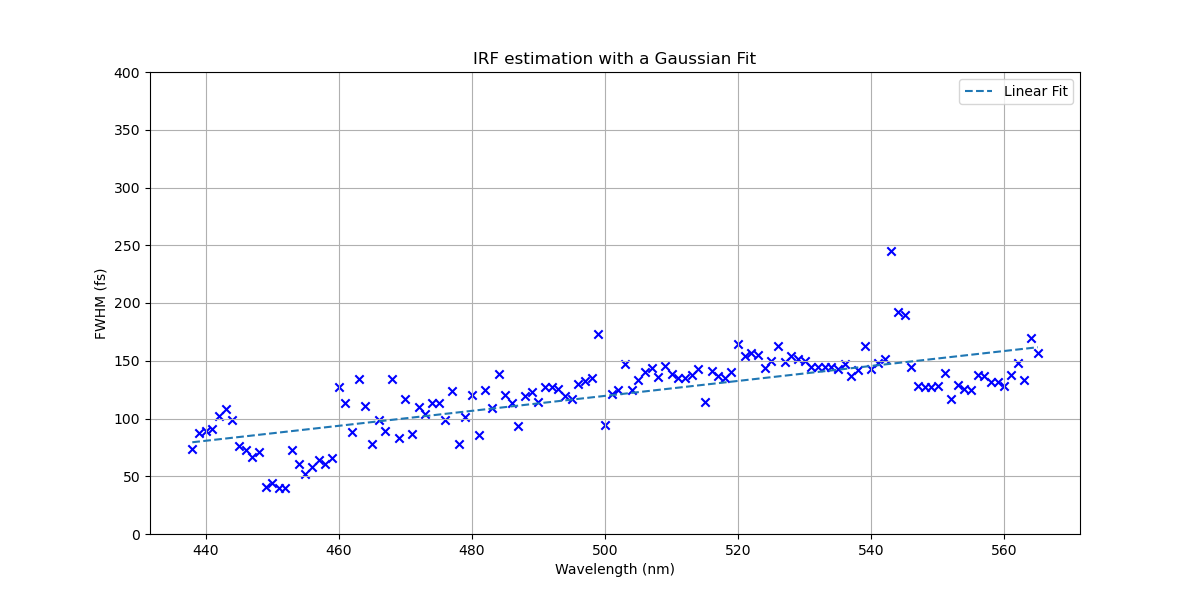

In [381]:
from scipy.stats import zscore

lower_signal_bound = 438
higher_singal_bound = 565
threshold = 0.0035

wl_range = np.arange(lower_signal_bound,higher_singal_bound+1,1)



ROI = dataset_cuvette.sel(spectral=slice(lower_signal_bound, higher_singal_bound))

ROI_FWHM_values = []
gaussian_fit_param = np.zeros([np.shape(wl_range)[0],3])
i = 0


for spectral_value in wl_range: 
    # Extract the kinetic trace for the selected spectral value
    kinetic_trace = np.abs(ROI['data'].sel(spectral=spectral_value, method='nearest'))

    # Find peaks in the kinetic trace
    peaks, _ = find_peaks(kinetic_trace)
    filtered_peaks = peaks[kinetic_trace[peaks] > threshold]

    # Ensure we have at least two peaks
    if len(filtered_peaks) >= 2:
        # Identify the two outermost peaks
        first_peak = filtered_peaks[0]
        last_peak = filtered_peaks[-1]
    # Create a mask where values between the two outermost peaks are removed
        mask = np.ones_like(kinetic_trace, dtype=bool)  
        mask[first_peak:last_peak+1] = False  
        
        # Apply the mask to the data
        sliced_kinetics = kinetic_trace.where(mask) 

        # Fit a Gaussian to the sliced data
        time_data = time_data = np.concatenate([sliced_kinetics.time[0:first_peak].values, sliced_kinetics.time[last_peak+1:].values], axis=0)
        kinetic_data = sliced_kinetics.data[~np.isnan(sliced_kinetics.data)] #Remove the NaN values, needed for the fit 

        # Define Gaussian model
        gauss_model = GaussianModel()

        # Set initial parameters
        gap_center = (sliced_kinetics.time[first_peak].values + sliced_kinetics.time[last_peak].values) / 2
        params = gauss_model.make_params(amplitude=ROI['data'].max().item(), center=gap_center, sigma=np.std(time_data))

        # Fit the model to the data
        fit_result = gauss_model.fit(kinetic_data, params, x=time_data) 

        # Generate smooth fitted curve
        smooth_time = np.linspace(time_data.min(), time_data.max(), 300)
        fitted_curve = gauss_model.eval(fit_result.params, x=smooth_time)

        #Print fitted parameters
        fitted_params = fit_result.params
        gaussian_fit_param[i][0] = fitted_params['amplitude'].value
        gaussian_fit_param[i][1] = fitted_params['center'].value
        gaussian_fit_param[i][2] = fitted_params['sigma'].value
        ROI_FWHM_values.append(gaussian_fwhm(fitted_params['sigma'].value*1000))
        i = i+1
    else:
        fwhm = calculate_fwhm(kinetic_trace, kinetic_trace.time.values)*1000 
        ROI_FWHM_values.append(fwhm)
        i = i+1

mask = np.abs(zscore(ROI_FWHM_values)) < 2.5
filtered_wl = wl_range[mask]
ROI_FWHM_values = np.array(ROI_FWHM_values)
filtered_fwhm = ROI_FWHM_values[mask]
fwhm_trend_cuvette,_ = curve_fit(lin,filtered_wl,filtered_fwhm)
fwhm_lin_cuvette = lin(wl_range,*fwhm_trend_cuvette)
plt.figure(figsize=(12, 6))
plt.scatter(wl_range,ROI_FWHM_values,color='blue', marker='x')
plt.plot(wl_range,fwhm_lin_cuvette, '--', label='Linear Fit') 
plt.legend()
plt.ylim([0,400])
plt.title('IRF estimation with a Gaussian Fit')
plt.grid('On')
plt.xlabel("Wavelength (nm)")
plt.ylabel("FWHM (fs)")



<Figure size 1200x600 with 0 Axes>

Text(0.5, 1.0, 'IRF estimation with a Gaussian Fit')

Text(0, 0.5, 'Wavelength (nm)')

Text(0.5, 0, 'position CA - ps')

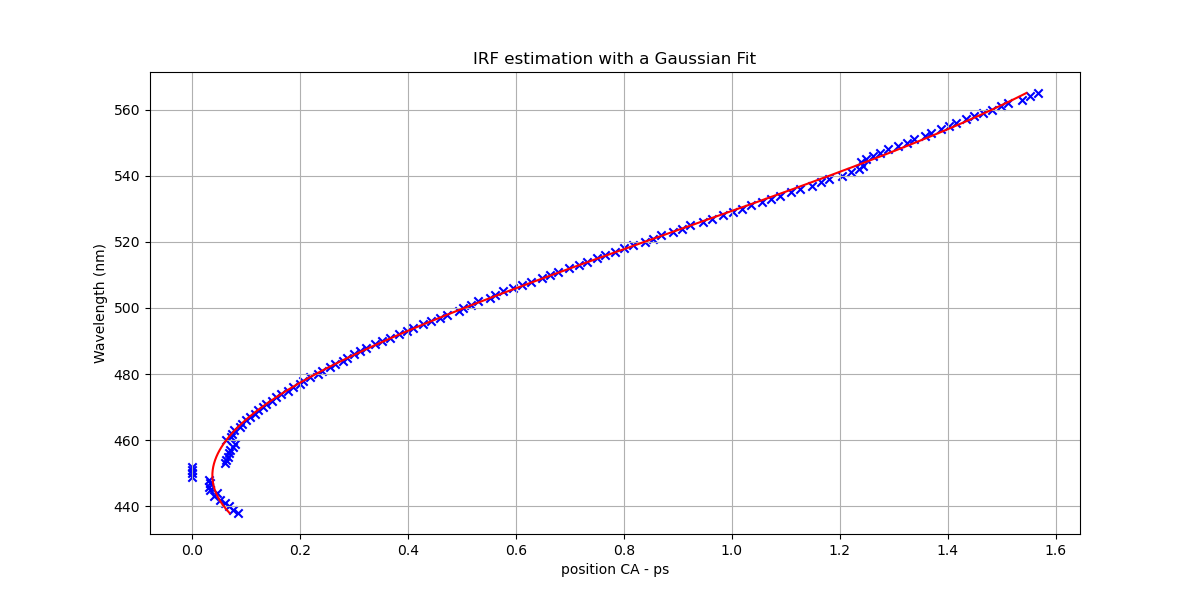

In [382]:
params_position_IRF_cuvette, _ = curve_fit(poly4, wl_range, gaussian_fit_param[:,1])
Fit_coherence_cuvette = poly4(wl_range,*params_position_IRF_cuvette)


plt.figure(figsize=(12, 6))
plt.scatter(gaussian_fit_param[:,1],wl_range,color='blue', marker='x')
plt.plot(Fit_coherence_cuvette,wl_range,  '-', label='Fit', color = 'red')
plt.title('IRF estimation with a Gaussian Fit')
plt.grid('On')
plt.ylabel("Wavelength (nm)")
plt.xlabel("position CA - ps")

(-0.06, 0.44)

Text(0.5, 0, 'Time (ps)')

Text(0, 0.5, 'ΔA')

Text(0.5, 0, 'Time (ps)')

Text(0, 0.5, 'Residual')

(-0.06, 0.44)

(-0.016108141642051262, 0.02970567170344547)

Text(0.5, 0.98, 'Modeling Coherent Artifact, cuvette scan, 469 nm')

[[Fit Statistics]]
    # fitting method   = leastsq
    # function evals   = 80
    # data points      = 48
    # variables        = 6
    chi-square         = 5.1425e-05
    reduced chi-square = 1.2244e-06
    Akaike info crit   = -647.836367
    Bayesian info crit = -636.609161
[[Variables]]
    B:          105.901262 +/- 17.7676129 (16.78%) (init = 200.2462)
    Phi:        155.198051 +/- 0.05610663 (0.04%) (init = 155.5085)
    A0:        -0.09020675 +/- 0.01672573 (18.54%) (init = -0.06680426)
    A1:         6.3265e-04 +/- 1.3211e-04 (20.88%) (init = 0.00053965)
    CA_FWHM:    0.12874905 +/- 0.00338988 (2.63%) (init = 0.09950072)
    CA_center:  0.13598896 +/- 6.6437e-04 (0.49%) (init = 0.1205692)
[[Correlations]] (unreported correlations are < 0.100)
    C(Phi, A0)       = -0.9908
    C(B, Phi)        = -0.9897
    C(B, A0)         = +0.9800
    C(A0, CA_FWHM)   = +0.8595
    C(Phi, CA_FWHM)  = -0.8278
    C(B, CA_FWHM)    = +0.7820
    C(Phi, A1)       = +0.6601
    C(A0, A1) 

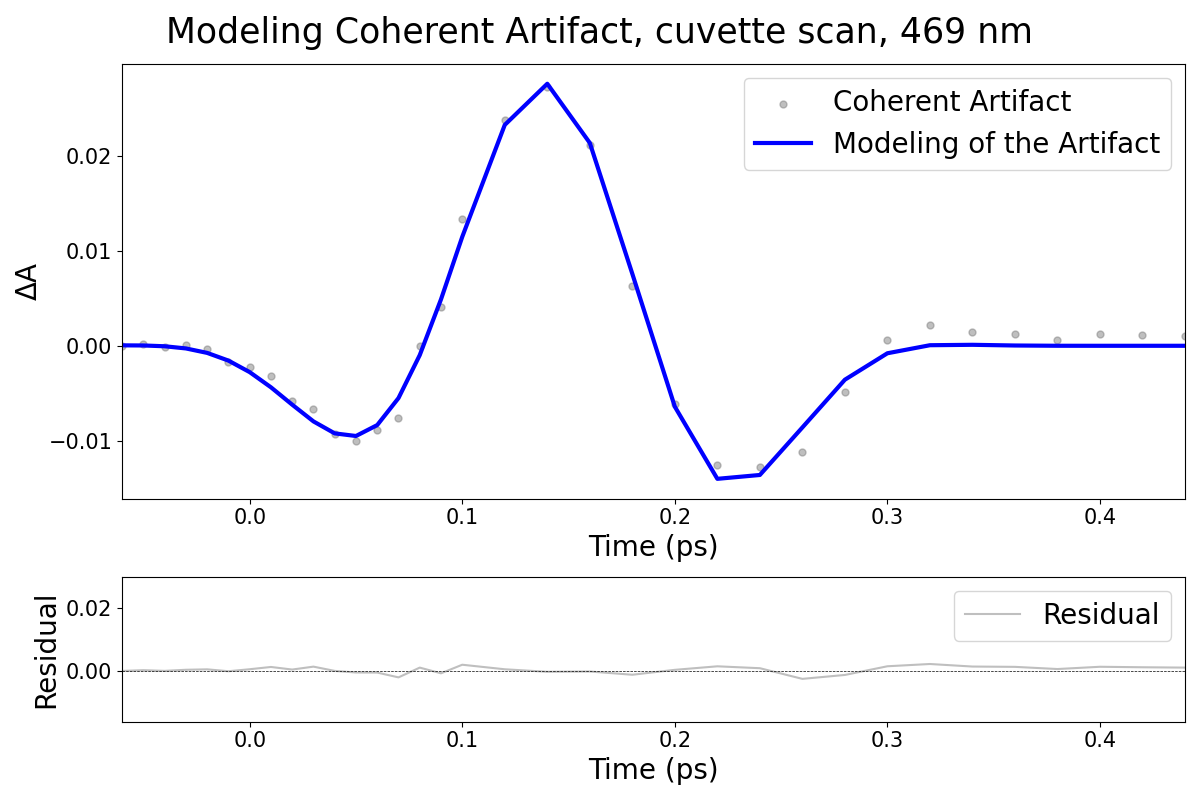

In [392]:
wv_1 = 469 #in nm


single_trace = xml_region.sel(spectral = [wv_1], method="nearest")
max_time = single_trace['time'][single_trace.argmax().item()].item()
single_trace = single_trace.sel(time = slice(max_time-0.5,max_time+0.5)) #Looks at -500 and +500 fs around the CA peak 
time = single_trace.time.values
data = single_trace.values.reshape(np.shape(single_trace.data)[0])

# Set up lmfit parameters
params = lmfit.Parameters()
params.add('B', value=  200.246245 , min = 0,vary = True) #determines how quickly the fringe periodicity increases 
params.add('Phi', value=155.508536   ,vary = True) #phase shift of the modulation 
params.add('A0', value=  -0.06680426     , vary = True) #Amplitude main Gaussian. Positve results in main peak down 
params.add('A1', value=5.3965e-04, vary = True) # help fit of asymmetric artifacts 
params.add('CA_FWHM', value= lin(469,*fwhm_trend_cuvette)/1000,min=0, vary = True) #FWHM 
params.add('CA_center', value=  poly4(469,*params_position_IRF_cuvette), vary = True) #Center of the chirp 


minimizer = lmfit.Minimizer(residuals_Fcos, params, fcn_args=(time, data))
result_init_cuvette = minimizer.minimize()

x_lims = [max_time-0.2,max_time+0.3]
fig, (ax, ax2) = plt.subplots(nrows=2, gridspec_kw={'height_ratios': [3, 1]}, figsize=(12, 8))
ax.scatter(time, data, color='grey', s=25, label='Coherent Artifact', alpha=0.5)
ax.plot(time, Fcos(result_init_cuvette.params, time), color='blue', linewidth=3, label='Modeling of the Artifact')
ax.set_xlim(x_lims)


residuals = data - Fcos(result_init_cuvette.params, time)
ax2.plot(time, residuals, color='grey', label='Residual', alpha=0.5)

ax.set_xlabel("Time (ps)",fontsize=20)
ax.set_ylabel("ΔA",fontsize=20)
ax2.set_xlabel("Time (ps)",fontsize=20)
ax2.set_ylabel("Residual",fontsize=20)  
ax2.axhline(0, color='black', linewidth=0.5, linestyle='--')
ax2.set_xlim(ax.get_xlim()) 
ax2.set_ylim(ax.get_ylim()) 
ax.tick_params(axis='both', which='major', labelsize=15)
ax2.tick_params(axis='both', which='major', labelsize=15)

handles, labels = ax.get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()

ax.legend(handles,labels, loc='upper right',fontsize = 20)
ax2.legend(handles2, labels2, loc='upper right',fontsize = 20)
fig.suptitle(f"Modeling Coherent Artifact, cuvette scan, {wv_1} nm",fontsize=25)
plt.tight_layout()



# Print the fit report
print(lmfit.fit_report(result_init_cuvette))

In [398]:
xml_region.min().item()

-0.009787345744680853

Text(0.5, 1.0, 'Fit')

Text(0.5, 0, 'Time (ps)')

Text(0, 0.5, '∆A')

Text(0.5, 1.0, 'Solvent Scan')

Text(0.5, 0, 'Time (ps)')

Text(0, 0.5, '∆A')

Text(0.5, 1.0, 'Difference')

Text(0.5, 0, 'Time (ps)')

Text(0, 0.5, '∆A')

(0.0, 1.0, 0.0, 1.0)

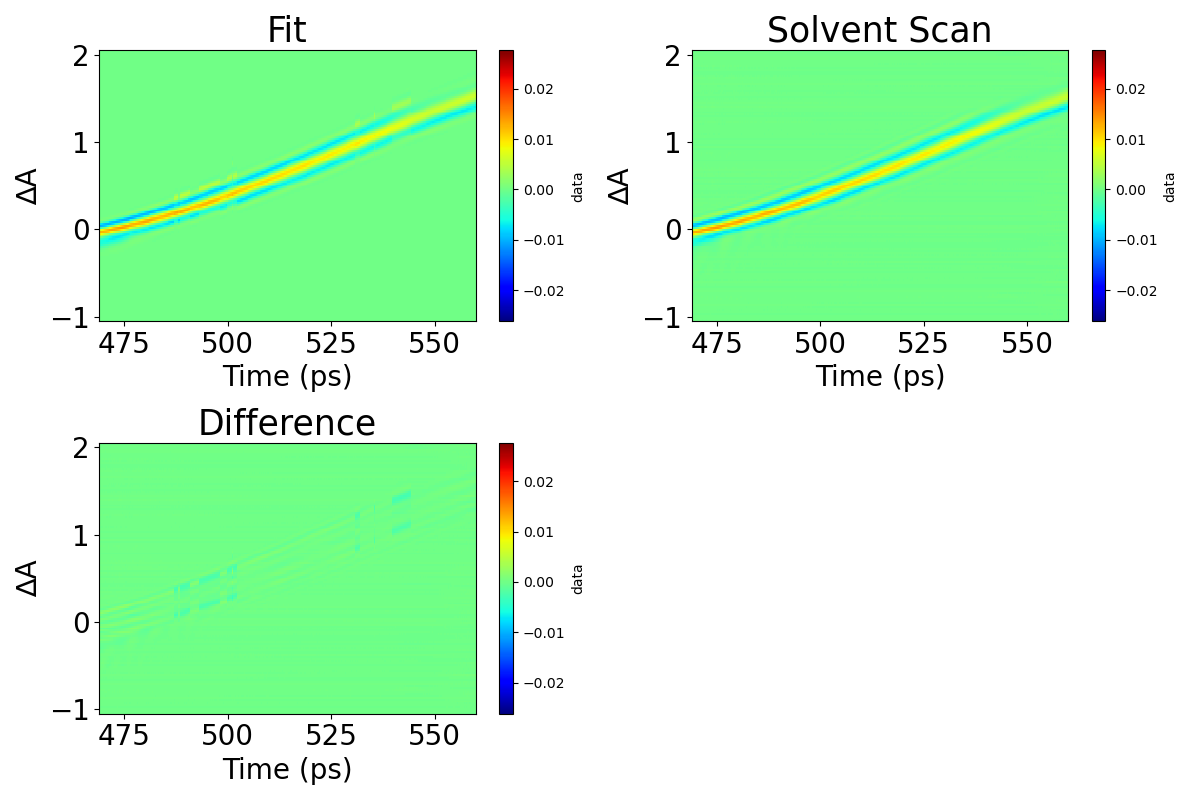

0.18569841449457994


In [407]:
lower_end = wv_1
higher_end = 560

xml_region = dataset_cuvette.data.sel(spectral=slice(wv_1, higher_end)).sel(time=slice(-1,2))
fit_CA_param_cuvette = {}
fit_CA_result_cuvette = np.transpose(np.zeros_like(xml_region))

for i, wavelength in enumerate(xml_region.spectral):
    single_trace = xml_region.sel(spectral=[wavelength], method="nearest")
    time = single_trace.time.values
    data = single_trace.values.reshape(np.shape(single_trace.data)[0])

    if i == 0:
        # Set up lmfit parameters for the first wavelength

        params = lmfit.Parameters()
        params.add('B', value= result_init_cuvette.params['B'].value , min = 0,vary = False) #determines how quickly the fringe periodicity increases 
        params.add('Phi', value=result_init_cuvette.params['Phi'].value  ,vary = False) #phase shift of the modulation 
        params.add('A0', value=  result_init_cuvette.params['A0'].value     , vary = False) #Amplitude main Gaussian. Positve results in main peak down 
        params.add('A1', value=result_init_cuvette.params['A1'].value, vary = False) # help fit of asymmetric artifacts 
        params.add('CA_FWHM', value= result_init_cuvette.params['CA_FWHM'].value,min=0, vary = False) #FWHM 
        params.add('CA_center', value= result_init_cuvette.params['CA_center'].value, vary = False) #Center of the chirp 
    else:
        # Use the previous wavelength's fitted parameters as initial values
        prev_wavelength = xml_region.spectral[i - 1].item()
        prev_params = fit_CA_param[prev_wavelength]
        params = lmfit.Parameters()
        for name, param in prev_params.items():
            params.add(name, value=param.value, vary=True) #, min=param.value*0.5, max=param.value*1.5

    # Perform minimization
    minimizer = lmfit.Minimizer(residuals_Fcos, params, fcn_args=(time, data))
    result_cuvette = minimizer.minimize()

    # Store the fit result in the dictionary to be used for the next wavelength
    fit_CA_param_cuvette[wavelength.item()] = result_cuvette.params
    fit_CA_result_cuvette[i] = Fcos(result_cuvette.params, time)


dataset_fit_CA_cuvette = xr.Dataset(
    {
        "data": (["time","spectral",], np.transpose(fit_CA_result_cuvette))
    },
    coords={
        "time": xml_region.time,
        "spectral": xml_region.spectral
    }
)

vmin = min(dataset_fit_CA_cuvette['data'].min().item(), xml_region.min().item(), diff['data'].min().item())
vmax = max(dataset_fit_CA_cuvette['data'].max().item(), xml_region.max().item(), diff['data'].max().item()) 

# Assuming dataset_fit and dataset_fit2 are already defined
fig, axes = plt.subplots(2, 2, figsize=(12, 8))  # 1 row, 2 columns

# Plot the first dataset
dataset_fit_CA_cuvette['data'].plot.imshow(ax=axes[0, 0],vmin=vmin, vmax=vmax,cmap='jet')
axes[0, 0].set_title("Fit",fontsize=25)
axes[0, 0].set_aspect("auto")  # Set aspect ratio
axes[0, 0].set_xlabel("Time (ps)",fontsize=20)
axes[0, 0].set_ylabel("∆A",fontsize=20)
axes[0, 0].tick_params(axis='both', which='major', labelsize=20)


# Plot the second dataset
xml_region.plot.imshow(ax=axes[0, 1],vmin=vmin, vmax=vmax,cmap='jet')
axes[0, 1].set_title("Solvent Scan",fontsize=25)
axes[0, 1].set_aspect("auto")  # Set aspect ratio
axes[0, 1].set_xlabel("Time (ps)",fontsize=20)
axes[0, 1].set_ylabel("∆A",fontsize=20)
axes[0, 1].tick_params(axis='both', which='major', labelsize=20)

diff = xml_region - dataset_fit_CA_cuvette
diff['data'].plot.imshow(ax=axes[1, 0],vmin=vmin, vmax=vmax,cmap='jet')
axes[1, 0].set_title("Difference",fontsize=25)
axes[1, 0].set_aspect("auto")  # Set aspect ratio
axes[1, 0].set_xlabel("Time (ps)",fontsize=20)
axes[1, 0].set_ylabel("∆A",fontsize=20)
axes[1, 0].tick_params(axis='both', which='major', labelsize=20)

# Hide the second subplot in the second row
axes[1, 1].axis('off')



plt.tight_layout()
plt.show();

Q1 = np.sqrt(np.mean((xml_region.data - dataset_fit_CA_cuvette.data)**2)) / np.sqrt(np.mean((xml_region.data)**2))
print(Q1.values)

(0.040000000000000036, 1.04)

Text(0.5, 0, 'Time (ps)')

Text(0, 0.5, 'ΔA')

Text(0.5, 0, 'Time (ps)')

Text(0, 0.5, 'Residual')

(0.040000000000000036, 1.04)

(-0.01154691306885164, 0.020323555478681483)

Text(0.5, 0.98, 'Modeling Coherent Artifact, cuvette scan, 500 nm')

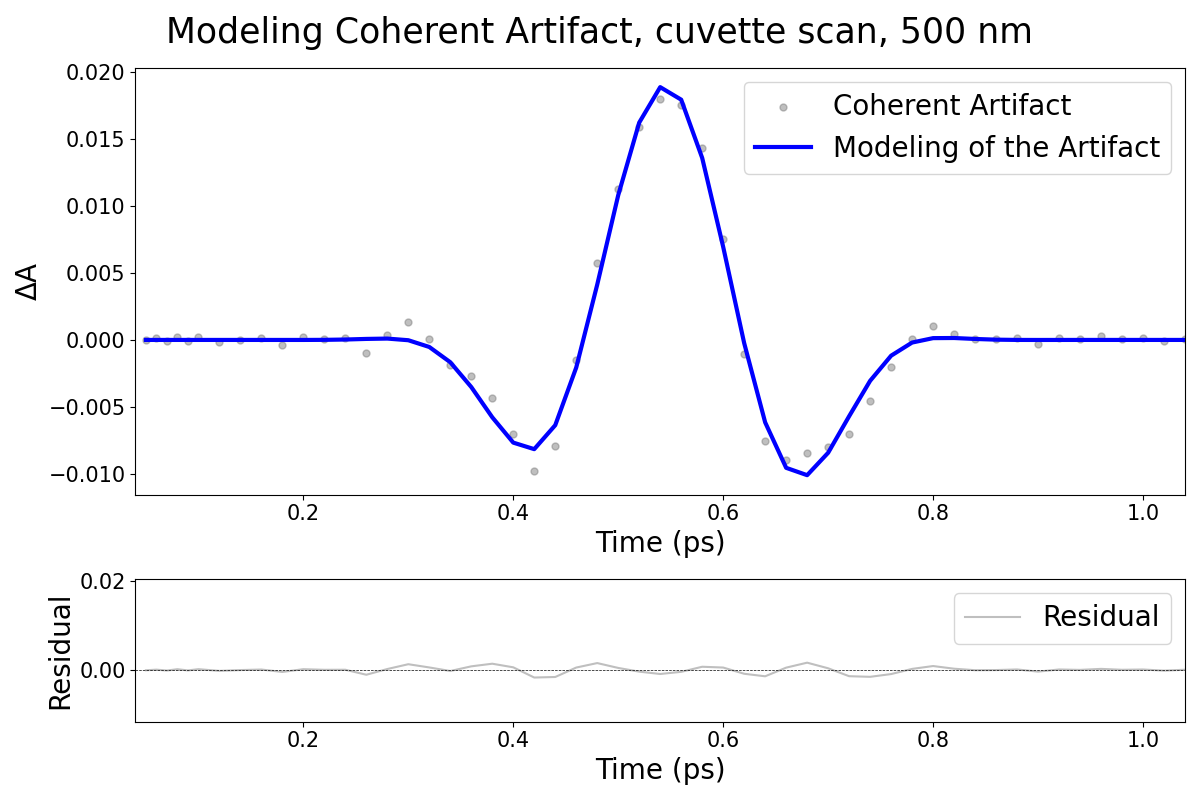

In [408]:
wv = 500 #in nm

xml_region = dataset_solvent.data.sel(spectral=slice(lower_end, higher_end)).sel(time=slice(-1,2))
single_trace = xml_region.sel(spectral = [wv], method="nearest")
max_time = single_trace['time'][single_trace.argmax().item()].item()
single_trace = single_trace.sel(time = slice(max_time-0.5,max_time+0.5)) #Looks at -500 and +500 fs around the CA peak 
time = single_trace.time.values
data = single_trace.values.reshape(np.shape(single_trace.data)[0])
x_lims = [max_time-0.5,max_time+0.5]

fit_fcos =  dataset_fit_CA['data'].sel(spectral = [wv], method = "nearest").sel(time = slice(max_time-0.5,max_time+0.5))
fit_fcos = fit_fcos.values.reshape(np.shape(single_trace.data)[0])

fig, (ax, ax2) = plt.subplots(nrows=2, gridspec_kw={'height_ratios': [3, 1]}, figsize=(12, 8))
ax.scatter(time, data, color='grey', s=25, label='Coherent Artifact', alpha=0.5)
ax.plot(time, fit_fcos, color='blue', linewidth=3, label='Modeling of the Artifact')
ax.set_xlim(x_lims)


residuals = data - fit_fcos
ax2.plot(time, residuals, color='grey', label='Residual', alpha=0.5)

ax.set_xlabel("Time (ps)",fontsize=20)
ax.set_ylabel("ΔA",fontsize=20)
ax2.set_xlabel("Time (ps)",fontsize=20)
ax2.set_ylabel("Residual",fontsize=20)  
ax2.axhline(0, color='black', linewidth=0.5, linestyle='--')
ax2.set_xlim(ax.get_xlim()) 
ax2.set_ylim(ax.get_ylim()) 
ax.tick_params(axis='both', which='major', labelsize=15)
ax2.tick_params(axis='both', which='major', labelsize=15)


handles, labels = ax.get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()

ax.legend(handles,labels, loc='upper right',fontsize = 20)
ax2.legend(handles2, labels2, loc='upper right',fontsize = 20)
fig.suptitle(f"Modeling Coherent Artifact, cuvette scan, {wv} nm",fontsize=25)
plt.tight_layout()

# Double Coherent Artifact fitting 

In [438]:
def Fcos_2(params, time): 
    B_cuvette = params['B_cuvette']
    Phi_cuvette = params['Phi_cuvette']
    A0_cuvette= params['A0_cuvette']
    A1_cuvette = params['A1_cuvette']
    tau_cuvette = params['tau_cuvette']
    dt0_cuvette = params['dt0_cuvette']
    
    cos_term_cuvette = np.cos(B_cuvette * (time - dt0_cuvette)**2 + Phi_cuvette) 
    exp_term_cuvette = A0_cuvette * np.exp(-4 * np.log(2) * ((time - dt0_cuvette) ** 2) / (tau_cuvette ** 2))
    correction_term_cuvette = A1_cuvette * (8 * np.log(2) / (tau_cuvette ** 2)) * (time - dt0_cuvette) * np.exp(-4 * np.log(2) * ((time - dt0_cuvette) ** 2) / (tau_cuvette ** 2))



    B_solvent = params['B_solvent']
    Phi_solvent = params['Phi_solvent']
    A0_solvent = params['A0_solvent']
    A1_solvent = params['A1_solvent']
    tau_solvent = params['tau_solvent']
    dt0_solvent = params['dt0_solvent']
    
    cos_term_solvent = np.cos(B_solvent * (time - dt0_solvent)**2 + Phi_solvent) 
    exp_term_solvent = A0_solvent * np.exp(-4 * np.log(2) * ((time - dt0_solvent) ** 2) / (tau_solvent ** 2))
    correction_term_solvent = A1_solvent * (8 * np.log(2) / (tau_solvent ** 2)) * (time - dt0_solvent) * np.exp(-4 * np.log(2) * ((time - dt0_solvent) ** 2) / (tau_solvent ** 2))
    
    result_solvent = cos_term_solvent * (exp_term_solvent - correction_term_solvent)
    result_cuvette = cos_term_cuvette * (exp_term_cuvette - correction_term_cuvette) 
    
    return result_solvent + result_cuvette

def Fcos_cuvette(params, time): 
    B_cuvette = params['B_cuvette']
    Phi_cuvette = params['Phi_cuvette']
    A0_cuvette= params['A0_cuvette']
    A1_cuvette = params['A1_cuvette']
    tau_cuvette = params['tau_cuvette']
    dt0_cuvette = params['dt0_cuvette']
    
    cos_term_cuvette = np.cos(B_cuvette * (time - dt0_cuvette)**2 + Phi_cuvette) 
    exp_term_cuvette = A0_cuvette * np.exp(-4 * np.log(2) * ((time - dt0_cuvette) ** 2) / (tau_cuvette ** 2))
    correction_term_cuvette = A1_cuvette * (8 * np.log(2) / (tau_cuvette ** 2)) * (time - dt0_cuvette) * np.exp(-4 * np.log(2) * ((time - dt0_cuvette) ** 2) / (tau_cuvette ** 2))

    result_cuvette = cos_term_cuvette * (exp_term_cuvette - correction_term_cuvette) 
    
    return result_cuvette

def Fcos_solvent(params, time): 
    B_solvent = params['B_solvent']
    Phi_solvent = params['Phi_solvent']
    A0_solvent = params['A0_solvent']
    A1_solvent = params['A1_solvent']
    tau_solvent = params['tau_solvent']
    dt0_solvent = params['dt0_solvent']
    
    cos_term_solvent = np.cos(B_solvent * (time - dt0_solvent)**2 + Phi_solvent) 
    exp_term_solvent = A0_solvent * np.exp(-4 * np.log(2) * ((time - dt0_solvent) ** 2) / (tau_solvent ** 2))
    correction_term_solvent = A1_solvent * (8 * np.log(2) / (tau_solvent ** 2)) * (time - dt0_solvent) * np.exp(-4 * np.log(2) * ((time - dt0_solvent) ** 2) / (tau_solvent ** 2))
    

    result_solvent = cos_term_solvent * (exp_term_solvent - correction_term_solvent)
    
    return result_solvent

def residuals_Fcos_2(params,time,data):
        model_vals = Fcos_2(params,time)
        resid = np.sqrt((model_vals - data)**2)
        return resid

(0.56, 1.06)

Text(0.5, 0, 'Time (ps)')

Text(0, 0.5, 'ΔA')

Text(0.5, 0, 'Time (ps)')

Text(0, 0.5, 'Residual')

(0.56, 1.06)

(-0.008597217246819586, 0.01570913764975081)

Text(0.5, 0.98, 'Modeling Coherent Artifact, solvent scan, 515 nm')

[[Fit Statistics]]
    # fitting method   = leastsq
    # function evals   = 57
    # data points      = 51
    # variables        = 5
    chi-square         = 7.1698e-05
    reduced chi-square = 1.5586e-06
    Akaike info crit   = -677.218852
    Bayesian info crit = -667.559724
[[Variables]]
    B_cuvette:    103.2946 (fixed)
    Phi_cuvette:  155.0711 (fixed)
    A0_cuvette:  -0.01832056 (fixed)
    A1_cuvette:   8.381214e-05 (fixed)
    tau_cuvette:  0.1879485 (fixed)
    dt0_cuvette:  0.7449671 (fixed)
    B_solvent:    94.8472441 +/- 7.88709368 (8.32%) (init = 200.2462)
    Phi_solvent:  154.9428 (fixed)
    A0_solvent:  -0.01610868 +/- 0.00125622 (7.80%) (init = -0.06680426)
    A1_solvent:  -9.2366e-05 +/- 1.1684e-04 (126.49%) (init = 8.381214e-05)
    tau_solvent:  0.18162001 +/- 0.01180407 (6.50%) (init = 0.2248279)
    dt0_solvent:  0.78831464 +/- 0.00331089 (0.42%) (init = 0.808554)
[[Correlations]] (unreported correlations are < 0.100)
    C(A0_solvent, tau_solvent) = +0.4

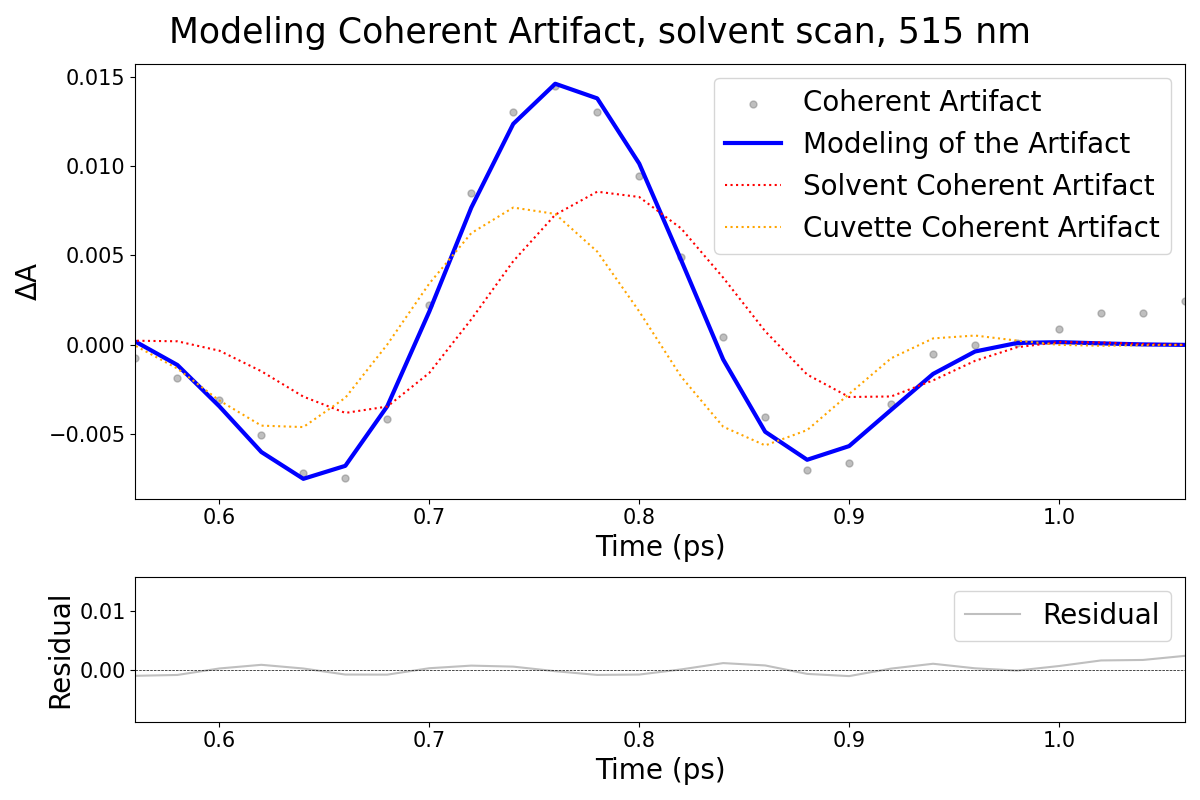

In [483]:
wv_1 = 515 #in nm

xml_region = dataset_dmp.data.sel(spectral=slice(430, 560))
single_trace = xml_region.sel(spectral = [wv_1], method="nearest")
max_time = single_trace['time'][single_trace.argmax().item()].item()
single_trace = single_trace.sel(time = slice(max_time-0.5,max_time+0.5)) #Looks at -500 and +500 fs around the CA peak 
time = single_trace.time.values
data = single_trace.values.reshape(np.shape(single_trace.data)[0])


p = fit_CA_param_cuvette[single_trace.spectral.item()]

params = lmfit.Parameters()
params.add('B_cuvette', value= p['B'].value,min=4.63391459,max=103.294567,vary = False) #determines how quickly the fringe periodicity increases 
params.add('Phi_cuvette',value= p['Phi'].value,min=155.071145,max=155.25559,vary = False) #phase shift of the modulation 
params.add('A0_cuvette', value= p['A0'].value , min=-0.0818767,max=-0.0128663,vary = False) #Amplitude main Gaussian. Positve results in main peak down 
params.add('A1_cuvette',value= p['A1'].value,min=-0.0016431,max=0.0012804, vary = False) # help fit of asymmetric artifacts 
params.add('tau_cuvette',value= p['CA_FWHM'].value,min=0.12486106,max=0.30933315 ,vary = False) # FWHM
params.add('dt0_cuvette',value= p['CA_center'].value ,min=-0.0602895,max= 1.76454641,vary = False)  #Center of the chirp

params.add('B_solvent', value=  200.246245 , min = 0,vary = True) #determines how quickly the fringe periodicity increases 
params.add('Phi_solvent', value=p['Phi'].value   ,vary = False) #phase shift of the modulation 
params.add('A0_solvent', value=  -0.06680426     , vary = True) #Amplitude main Gaussian. Positve results in main peak down 
params.add('A1_solvent', value=p['A1'], vary = True) # help fit of asymmetric artifacts 
params.add('tau_solvent', value= lin(wv_1,*fwhm_trend_solvent)/1000,min=0, vary = True) #FWHM 
params.add('dt0_solvent', value=  poly4(wv_1,*params_position_IRF_solvent), vary = True) #Center of the chirp 


minimizer = lmfit.Minimizer(residuals_Fcos_2, params, fcn_args=(time, data))
result = minimizer.minimize()

x_lims = [max_time-0.2,max_time+0.3]
fig, (ax, ax2) = plt.subplots(nrows=2, gridspec_kw={'height_ratios': [3, 1]}, figsize=(12, 8))
ax.scatter(time, data, color='grey', s=25, label='Coherent Artifact', alpha=0.5)
ax.plot(time, Fcos_2(result.params, time), color='blue', linewidth=3, label='Modeling of the Artifact')
ax.plot(time, Fcos_solvent(result.params, time), color='red',linestyle= 'dotted', label='Solvent Coherent Artifact')
ax.plot(time, Fcos_cuvette(result.params, time), color='orange',linestyle= 'dotted', label='Cuvette Coherent Artifact')
ax.set_xlim(x_lims)


residuals = data - Fcos_2(result.params, time)
ax2.plot(time, residuals, color='grey', label='Residual', alpha=0.5)

ax.set_xlabel("Time (ps)",fontsize=20)
ax.set_ylabel("ΔA",fontsize=20)
ax2.set_xlabel("Time (ps)",fontsize=20)
ax2.set_ylabel("Residual",fontsize=20)  
ax2.axhline(0, color='black', linewidth=0.5, linestyle='--')
ax2.set_xlim(ax.get_xlim()) 
ax2.set_ylim(ax.get_ylim()) 
ax.tick_params(axis='both', which='major', labelsize=15)
ax2.tick_params(axis='both', which='major', labelsize=15)

handles, labels = ax.get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()

ax.legend(handles,labels, loc='upper right',fontsize = 20)
ax2.legend(handles2, labels2, loc='upper right',fontsize = 20)
fig.suptitle(f"Modeling Coherent Artifact, solvent scan, {wv_1} nm",fontsize=25)
plt.tight_layout()



# Print the fit report
print(lmfit.fit_report(result))

<Figure size 640x480 with 0 Axes>

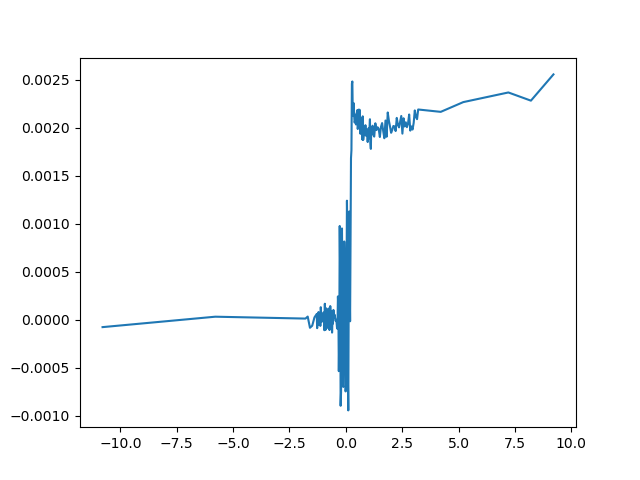

In [484]:
single_trace = xml_region.sel(spectral = [wv_1], method="nearest")
time = single_trace.time.values 
data = single_trace.values.reshape(np.shape(single_trace.data)[0])
residuals = data - Fcos_2(result.params, time)
time_corrected = time - result.params['dt0_solvent'].value
plt.figure()
plt.plot(time_corrected,residuals)
plt.show()

In [ ]:
# Loop 

# Fitting 

In [ ]:
scan_region= dataset_dmp.data.sel(spectral=slice(lower_end, higher_end))
wv_fit = 490



single_trace = scan_region.sel(spectral = [wv_fit], method="nearest") 
time = single_trace.time.values
data = single_trace.values.flatten()

#the A coef does need to be scaled
params = lmfit.Parameters()



params.add('B', value= fit_CA_param[single_trace.spectral.item()]['B'].value,min=4.63391459,max=103.294567,vary = True) #determines how quickly the fringe periodicity increases 
params.add('Phi',value= fit_CA_param[single_trace.spectral.item()]['Phi'].value,min=155.071145,max=155.25559,vary = True) #phase shift of the modulation 
params.add('A0', value=fit_CA_param[single_trace.spectral.item()]['A0'].value , min=-0.0818767,max=-0.0128663,vary = True) #Amplitude main Gaussian. Positve results in main peak down 
params.add('A1',value= fit_CA_param[single_trace.spectral.item()]['A1'].value,min=-0.0016431,max=0.0012804, vary = True) # help fit of asymmetric artifacts 
params.add('CA_FWHM',value= fit_CA_param[single_trace.spectral.item()]['CA_FWHM'].value,min=0.12486106,max=0.30933315 ,vary = True) # FWHM
params.add('CA_center',value=fit_CA_param[single_trace.spectral.item()]['CA_center'].value ,min=-0.0602895,max= 1.76454641,vary = True)  #Center of the chirp  

minimizer = lmfit.Minimizer(residuals_Fcos, params, fcn_args=(time, data))
result_initial_noC = minimizer.minimize('differential_evolution')



x_lims = [0,1]

fig, (ax, ax2) = plt.subplots(nrows=2, gridspec_kw={'height_ratios': [3, 1]}, figsize=(8, 6))
ax.scatter(time, data, color='grey', s=10, label='Data', alpha=0.5)
ax.plot(time, Fcos(result_initial_noC.params, time), color='blue', linewidth=1.5, label='Fit')
#ax.axvline(x= result.params['IRF_center'].value,color = 'k')
ax.grid('On')
ax.set_xlim(x_lims)


residuals = data - Fcos(result_initial_noC.params, time)
ax2.plot(time, residuals, color='grey', label='Residual', alpha=0.5)

ax.set_xlabel("Time (ps)")
ax.set_ylabel("ΔOD")
ax2.set_xlabel("Time (ps)")
ax2.set_ylabel("Residual")  
ax2.axhline(0, color='black', linewidth=0.5, linestyle='--')
ax2.set_xlim(ax.get_xlim())  
ax2.set_ylim(ax.get_ylim())  

handles, labels = ax.get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()
all_handles = handles + handles2
all_labels = labels + labels2
by_label = dict(zip(all_labels, all_handles))
ax.legend(by_label.values(), by_label.keys(), loc='upper right')
ax.legend(by_label.values(), by_label.keys(), loc='upper right')
fig.suptitle(f"Kinetic trace Cu(dmp)2 @ {wv_fit}nm")

plt.tight_layout()

data_noXPM = data - Fcos(result_initial_noC.params,time)


plt.figure(figsize=(8, 5))
plt.plot(time, data_noXPM, '-', label='Data')
plt.xlabel('Time')#plt.ylim ([-0.008,0.008])
plt.ylabel('Signal')
#plt.yscale('log')
plt.legend()
plt.show()

print(lmfit.fit_report(result_initial_noC))

In [ ]:
single_trace = scan_region.sel(spectral = [wv_fit], method="nearest") 
time = single_trace.time.values
data = single_trace.values.flatten()

#the A coef does need to be scaled
params = lmfit.Parameters()

p = result_initial_noC.params


params.add('B', value= p['B'].value,min=4.63391459,max=103.294567,vary = False) #determines how quickly the fringe periodicity increases 
params.add('Phi',value= p['Phi'].value,min=155.071145,max=155.25559,vary = False) #phase shift of the modulation 
params.add('A0', value= p['A0'].value , min=-0.0818767,max=-0.0128663,vary = False) #Amplitude main Gaussian. Positve results in main peak down 
params.add('A1',value= p['A1'].value,min=-0.0016431,max=0.0012804, vary = False) # help fit of asymmetric artifacts 
params.add('CA_FWHM',value= p['CA_FWHM'].value,min=0.12486106,max=0.30933315 ,vary = False) # FWHM
params.add('CA_center',value= p['CA_center'].value ,min=-0.0602895,max= 1.76454641,vary = False)  #Center of the chirp
params.add('const',value=0.02 ,min=-0.05,max= 0.05,vary = True)     
params.add('Signal_center',value=0.68 ,min=0,max= 1,vary = True)   


minimizer = lmfit.Minimizer(residuals_Fcos_c, params, fcn_args=(time, data))
result_initial = minimizer.minimize('differential_evolution')

CA_center_val = result_initial.params['CA_center'].value
CA_FWHM_val = result_initial.params['CA_FWHM'].value
t0 = result_initial.params['Signal_center'].value
time_corrected  = time - t0


x_lims = [0,10]

fig, (ax, ax2) = plt.subplots(nrows=2, gridspec_kw={'height_ratios': [3, 1]}, figsize=(8, 6))
ax.scatter(time_corrected, data, color='grey', s=10, label='Data', alpha=0.5)
ax.plot(time_corrected, Fcos_c(result_initial.params, time), color='blue', linewidth=1.5, label='Fit')
#ax.axvline(x= result.params['IRF_center'].value,color = 'k')
ax.grid('On')
ax.set_xlim(x_lims)


residuals = data - Fcos_c(result_initial.params, time)
ax2.plot(time_corrected, residuals, color='grey', label='Residual', alpha=0.5)

ax.set_xlabel("Time (ps)")
ax.set_ylabel("ΔOD")
ax2.set_xlabel("Time (ps)")
ax2.set_ylabel("Residual")  
ax2.axhline(0, color='black', linewidth=0.5, linestyle='--')
ax2.set_xlim(ax.get_xlim())  
ax2.set_ylim(ax.get_ylim())  

handles, labels = ax.get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()
all_handles = handles + handles2
all_labels = labels + labels2
by_label = dict(zip(all_labels, all_handles))
ax.legend(by_label.values(), by_label.keys(), loc='upper right')
ax.legend(by_label.values(), by_label.keys(), loc='upper right')
fig.suptitle(f"Kinetic trace Cu(dmp)2 @ {wv_fit}nm")

plt.tight_layout()


data_noXPM = data - Fcos(result_initial.params,time)

plt.figure(figsize=(8, 5))
plt.plot(time_corrected, data_noXPM, '-', label='Data')
plt.xlabel('Time (ps)')#plt.ylim ([-0.008,0.008])
plt.ylabel('Signal OD')
#plt.yscale('log')
#plt.legend()
plt.grid('On')
plt.show()


print(lmfit.fit_report(result_initial))
print(f'Least square sun :{np.sum(residuals_Fcos_c(result_initial.params,time,data))}')

# parrallel model

In [ ]:
single_trace = scan_region.sel(spectral = [wv_fit], method="nearest") 
time = single_trace.time.values
data = single_trace.values.flatten()

#the A coef does need to be scaled
params = lmfit.Parameters()

p = result_initial_noC.params
k = result_initial.params

params.add('B', value= p['B'].value,min=4.63391459,max=103.294567,vary = False) #determines how quickly the fringe periodicity increases 
params.add('Phi',value= p['Phi'].value,min=155.071145,max=155.25559,vary = False) #phase shift of the modulation 
params.add('A0', value= p['A0'].value , min=-0.0818767,max=-0.0128663,vary = False) #Amplitude main Gaussian. Positve results in main peak down 
params.add('A1',value= p['A1'].value,min=-0.0016431,max=0.0012804, vary = False) # help fit of asymmetric artifacts 
params.add('CA_FWHM',value= p['CA_FWHM'].value,min=0.12486106,max=0.30933315 ,vary = False) # FWHM
params.add('CA_center',value= p['CA_center'].value ,min=-0.0602895,max= 1.76454641,vary = False)  #Center of the chirp


params.add('A_S2',value=   -0.00301471 ,min=-.05,max=0.30933315 ,vary = False) 
params.add('tau_S2',value= 0.045 ,min=0,max= 1.76454641,vary = True)  

params.add('A_S1',value=   4.3513e-04  ,min=-.05,max= 0.5,vary = True)  
params.add('tau_S1',value=0.50839709 ,min=0.2,max= 2,vary = True)  

params.add('A_S1sq',value= 0.00156200,min=-0.05,max=0.05 ,vary = True) 
params.add('tau_S1sq',value= 7.4,min=3,max= 100,vary = True)  

params.add('t0',value= k['Signal_center'].value,min=k['Signal_center'].value-0.1,max=k['Signal_center'].value+0.1 ,vary = False) 
#params.add('constant',value= k['const'].value,min=0,max=3 ,vary = False) 
params.add('constant',value= 0,min=0,max=3 ,vary = False) 



minimizer = lmfit.Minimizer(SK_residuals_4exp, params, fcn_args=(time, data))
#result = minimizer.minimize('differential_evolution')
result = minimizer.minimize()

print(lmfit.fit_report(result))
print(f'Least square sun :{np.sum(SK_residuals_4exp(result.params,time,data))}')

t0 = result.params['t0'].value
time_corrected  = time - t0


x_lims = [-1,3]
#y_lims = [-0.006,0.006]

fig, (ax, ax2) = plt.subplots(nrows=2, gridspec_kw={'height_ratios': [3, 1]}, figsize=(8, 6))
ax.scatter(time_corrected, data, color='grey', s=10, label='Data', alpha=0.5)
ax.plot(time_corrected, SK_model_4exp(result.params, time), color='blue', linewidth=1.5, label='Fit')
#ax.axvline(x= result.params['IRF_center'].value,color = 'k')
ax.grid('On')
ax.set_xlim(x_lims)
#ax.set_ylim(y_lims)


residuals = SK_model_4exp(result.params, time) - data 
ax2.plot(time_corrected, residuals, color='grey', label='Residual', alpha=0.5)

ax.set_xlabel("Time (ps)")
ax.set_ylabel("ΔOD")
ax2.set_xlabel("Time (ps)")
ax2.set_ylabel("Residual")  
ax2.axhline(0, color='black', linewidth=0.5, linestyle='--')
ax2.set_xlim(ax.get_xlim())  
ax2.set_ylim(ax.get_ylim())  

handles, labels = ax.get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()
all_handles = handles + handles2
all_labels = labels + labels2
by_label = dict(zip(all_labels, all_handles))
ax.legend(by_label.values(), by_label.keys(), loc='upper right')
ax.legend(by_label.values(), by_label.keys(), loc='upper right')
fig.suptitle(f"Kinetic trace Cu(dmp)2 @ {wv_fit}nm - 3 exp")
plt.tight_layout();

data_noXPM = data - Fcos(result.params,time)


plt.figure(figsize=(8, 5))
plt.plot(time_corrected, data_noXPM, '-', label='Data')
plt.title(f"Data without XPM @ {wv_fit}nm - 3 exp")
plt.xlabel('Time')#plt.ylim ([-0.008,0.008])
plt.xlim(x_lims)
plt.ylabel('Signal')
#plt.yscale('log')
plt.legend()
plt.show();




In [ ]:
p = result.params

single_trace = scan_region.sel(spectral = [wv_fit], method="nearest") 
time = single_trace.time.values
data = single_trace.values.flatten()

exp_component = fit_4exp(p,time)

XMR =  Fcos(p, time)


data -= XMR

x_lims = [-1,2]
#y_lims = [-0.005,0.005]


fig, (ax, ax2) = plt.subplots(nrows=2, gridspec_kw={'height_ratios': [3, 1]}, figsize=(12, 8))
ax.scatter(time_corrected, data, color='grey', s=25, label='Data with CA removed', alpha=0.5)
ax.plot(time_corrected, exp_component,color='red', linewidth=3, label='Exp terms convoluted with IRF')
ax.set_xlim(x_lims)
#ax.set_ylim(y_lims)


residuals = data - exp_component
ax2.plot(time_corrected, residuals, color='grey', label='Residual', alpha=0.5)

ax.set_xlabel("Time (ps)",fontsize=20)
ax.set_ylabel("ΔOD",fontsize=20)
ax2.set_xlabel("Time (ps)",fontsize=20)
ax2.set_ylabel("Residual",fontsize=20)  
ax2.axhline(0, color='black', linewidth=0.5, linestyle='--')
ax2.set_xlim(ax.get_xlim())  
ax2.set_ylim(ax.get_ylim())

ax.tick_params(axis='both', which='major', labelsize=20)
ax2.tick_params(axis='both', which='major', labelsize=20)


handles, labels = ax.get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()
all_handles = handles #+ #handles2
all_labels = labels #+ labels2
by_label = dict(zip(all_labels, all_handles))
ax.legend(by_label.values(), by_label.keys(), loc='best',fontsize=15)
fig.suptitle(f"Kinetic trace @ {wv}nm")
fig.suptitle(f"exp Kinetic trace without Coherent Artifact 3exp @ {wv_fit}nm")
plt.tight_layout()


In [ ]:
single_trace = scan_region.sel(spectral = [wv_fit], method="nearest") 
time = single_trace.time.values
data = single_trace.values.flatten()

#the A coef does need to be scaled
params = lmfit.Parameters()

p = result_initial_noC.params
k = result_initial.params

params.add('B', value= p['B'].value,min=4.63391459,max=103.294567,vary = False) #determines how quickly the fringe periodicity increases 
params.add('Phi',value= p['Phi'].value,min=155.071145,max=155.25559,vary = False) #phase shift of the modulation 
params.add('A0', value= p['A0'].value , min=-0.0818767,max=-0.0128663,vary = False) #Amplitude main Gaussian. Positve results in main peak down 
params.add('A1',value= p['A1'].value,min=-0.0016431,max=0.0012804, vary = False) # help fit of asymmetric artifacts 
params.add('CA_FWHM',value= p['CA_FWHM'].value,min=0.12486106,max=0.30933315 ,vary = False) # FWHM
params.add('CA_center',value= p['CA_center'].value ,min=-0.0602895,max= 1.76454641,vary = False)  #Center of the chirp


params.add('A_S2',value= 0,min=0,max=0.30933315 ,vary = False) 
params.add('tau_S2',value= 0.045 ,min=-0.0602895,max= 1.76454641,vary = False)  

params.add('A_S1',value= 0 ,min=-0.5,max= 0.5,vary = True)  
params.add('tau_S1',value=0.660 ,min=0.2,max= 1.2,vary = True)  

params.add('A_S1sq',value= 0.00156200,min=-0.05,max=0.05 ,vary = True) 
params.add('tau_S1sq',value= 7.4,min=3,max= 100,vary = True)  

params.add('t0',value= k['Signal_center'].value,min=k['Signal_center'].value-0.1,max=k['Signal_center'].value+0.1 ,vary = False) 
#params.add('constant',value= k['const'].value,min=0,max=3 ,vary = True) 
params.add('constant',value= 0,min=0,max=3 ,vary = False) 



minimizer = lmfit.Minimizer(SK_residuals_4exp, params, fcn_args=(time, data))
#result = minimizer.minimize('differential_evolution')
result = minimizer.minimize('differential_evolution')

print(lmfit.fit_report(result))
print(f'Least square sun :{np.sum(SK_residuals_4exp(result.params,time,data))}')

t0 = result.params['t0'].value
time_corrected  = time - t0


x_lims = [-.1,2]
y_lims = [-0.003,0.003]

fig, (ax, ax2) = plt.subplots(nrows=2, gridspec_kw={'height_ratios': [3, 1]}, figsize=(8, 6))
ax.scatter(time_corrected, data, color='grey', s=10, label='Data', alpha=0.5)
ax.plot(time_corrected, SK_model_4exp(result.params, time), color='blue', linewidth=1.5, label='Fit')
#ax.axvline(x= result.params['IRF_center'].value,color = 'k')
ax.grid('On')
ax.set_xlim(x_lims)
ax.set_ylim(y_lims)


residuals = SK_model_4exp(result.params, time) - data 
ax2.plot(time_corrected, residuals, color='grey', label='Residual', alpha=0.5)

ax.set_xlabel("Time (ps)")
ax.set_ylabel("ΔOD")
ax2.set_xlabel("Time (ps)")
ax2.set_ylabel("Residual")  
ax2.axhline(0, color='black', linewidth=0.5, linestyle='--')
ax2.set_xlim(ax.get_xlim())  
#ax2.set_ylim(ax.get_ylim())  

handles, labels = ax.get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()
all_handles = handles + handles2
all_labels = labels + labels2
by_label = dict(zip(all_labels, all_handles))
ax.legend(by_label.values(), by_label.keys(), loc='upper right')
ax.legend(by_label.values(), by_label.keys(), loc='upper right')
fig.suptitle(f"Kinetic trace Cu(dmp)2 @ {wv_fit}nm - 2 exp ")

plt.tight_layout();

data_noXPM = data - Fcos(result.params,time)


plt.figure(figsize=(8, 5))
plt.plot(time_corrected, data_noXPM, '-', label='Data')
plt.title(f"Data without XPM @ {wv_fit}nm")
plt.xlabel('Time')#plt.ylim ([-0.008,0.008])
plt.xlim(x_lims)
plt.ylabel('Signal')
#plt.yscale('log')
plt.legend()
plt.show();


In [ ]:
p = result.params

single_trace = scan_region.sel(spectral = [wv_fit], method="nearest") 
time = single_trace.time.values
data = single_trace.values.flatten()

exp_component = fit_4exp(p,time)

XMR =  Fcos(p, time)


data -= XMR

x_lims = [-1,2]


fig, (ax, ax2) = plt.subplots(nrows=2, gridspec_kw={'height_ratios': [3, 1]}, figsize=(12, 8))
ax.scatter(time_corrected, data, color='grey', s=25, label='Data with CA removed', alpha=0.5)
ax.plot(time_corrected, exp_component,color='red', linewidth=3, label='Exp terms convoluted with IRF')
ax.set_xlim(x_lims)


residuals = data - exp_component
ax2.plot(time_corrected, residuals, color='grey', label='Residual', alpha=0.5)

ax.set_xlabel("Time (ps)",fontsize=20)
ax.set_ylabel("ΔOD",fontsize=20)
ax2.set_xlabel("Time (ps)",fontsize=20)
ax2.set_ylabel("Residual",fontsize=20)  
ax2.axhline(0, color='black', linewidth=0.5, linestyle='--')
ax2.set_xlim(ax.get_xlim())  
ax2.set_ylim(ax.get_ylim())  

ax.tick_params(axis='both', which='major', labelsize=20)
ax2.tick_params(axis='both', which='major', labelsize=20)


handles, labels = ax.get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()
all_handles = handles #+ #handles2
all_labels = labels #+ labels2
by_label = dict(zip(all_labels, all_handles))
ax.legend(by_label.values(), by_label.keys(), loc='best',fontsize=15)
fig.suptitle(f"Kinetic trace @ {wv}nm")
fig.suptitle(f"exp Kinetic trace without Coherent Artifact 2 exp @ {wv_fit}nm")
plt.tight_layout()


# Integral of the early peaks

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import lmfit

wavelengths = np.arange(440.0936680532078,  559.8618073104616  , 5)
integrals = []


for wv in wavelengths:
    single_trace = dataset_dchtmp_replicate.data.sel(spectral=[wv], method="nearest")
    time = single_trace.time.values
    data = single_trace.values.flatten()
    actual_wv = single_trace.spectral.item()

    params = lmfit.Parameters()
    p = fit_CA_param[actual_wv]
    params.add('B', value=p['B'].value, min=4.63391459, max=103.294567,vary = True)
    params.add('Phi', value=p['Phi'].value, min=155.071145, max=155.25559)
    params.add('A0', value=p['A0'].value, min=-0.0818767, max=-0.0128663)
    params.add('A1', value=p['A1'].value, min=-0.0016431, max=0.0012804)
    params.add('CA_FWHM', value=p['CA_FWHM'].value, min=0.12486106, max=0.30933315)
    params.add('CA_center', value=p['CA_center'].value, min=-0.0602895, max=1.76454641)
    params.add('const', value=0.02, min=-0.05, max=0.05)
    params.add('Signal_center',value=0.7 ,min=-0.5,max= 1,vary = True)  #Center of the chirp  

    minimizer = lmfit.Minimizer(residuals_Fcos_c, params, fcn_args=(time, data))
    result = minimizer.minimize(method='differential_evolution')

    CA_center_val = result.params['CA_center'].value
    time_corr = time - CA_center_val

    residual = residuals_Fcos_c(result.params, time, data)

    mask = (time_corr >= 0.01) & (time_corr <= 0.50)
    integral = np.trapz(np.abs(residual[mask]), time_corr[mask])
    integrals.append(integral)


# Plot
plt.figure(figsize=(8, 5))
plt.plot(wavelengths, integrals, marker='o')
plt.xlabel("Wavelength (nm)")
plt.ylabel("Residual Integral (0.01 to 0.3 ps)")
plt.title("Integral of residual vs time for Cu(dmp)2 ")
plt.grid(True)
plt.tight_layout()
plt.show()


# FFT 

In [ ]:
from scipy.fft import fft, fftfreq

scan_region= dataset_dchtmp.data.sel(spectral=slice(lower_end, higher_end))
wv = 510



single_trace = scan_region.sel(spectral = [wv], method="nearest") 
time = single_trace.time.values
data = single_trace.values.flatten()

#the A coef does need to be scaled
params = lmfit.Parameters()



params.add('B', value= fit_CA_param[single_trace.spectral.item()]['B'].value,min=4.63391459,max=103.294567,vary = True) #determines how quickly the fringe periodicity increases 
params.add('Phi',value= fit_CA_param[single_trace.spectral.item()]['Phi'].value,min=155.071145,max=155.25559,vary = True) #phase shift of the modulation 
params.add('A0', value=fit_CA_param[single_trace.spectral.item()]['A0'].value , min=-0.0818767,max=-0.0128663,vary = True) #Amplitude main Gaussian. Positve results in main peak down 
params.add('A1',value= fit_CA_param[single_trace.spectral.item()]['A1'].value,min=-0.0016431,max=0.0012804, vary = True) # help fit of asymmetric artifacts 
params.add('CA_FWHM',value= fit_CA_param[single_trace.spectral.item()]['CA_FWHM'].value,min=0.12486106,max=0.30933315 ,vary = True) # FWHM
params.add('CA_center',value=fit_CA_param[single_trace.spectral.item()]['CA_center'].value ,min=-0.0602895,max= 1.76454641,vary = True)  #Center of the chirp
params.add('const',value=0.02 ,min=-0.05,max= 0.05,vary = True)  #Center of the chirp    
params.add('Signal_center',value=0.7 ,min=-0.5,max= 1,vary = True)  #Center of the chirp 

minimizer = lmfit.Minimizer(residuals_Fcos_c, params, fcn_args=(time, data))
result_initial = minimizer.minimize('differential_evolution')

CA_center_val = result_initial.params['CA_center'].value
time_corrected = time - CA_center_val 

residuals = data - Fcos_c(result_initial.params, time)

mask = (time_corrected >= 0.05) & (time_corrected <= 2)
t = time_corrected[mask]
res = residuals[mask]


dt = t[1] - t[0]  # sampling interval in ps
N = len(t)
freq = fftfreq(N, d=dt)  # in THz

# Convert to wavenumbers (cm⁻¹): 1 THz ≈ 33.356 cm⁻¹
wavenumbers = freq * 33.356
spectrum = np.abs(fft(res-np.mean(res))) 

valid = (wavenumbers > 0.1) & (wavenumbers < 1000)
plt.figure(figsize=(8, 5))
plt.plot(wavenumbers[valid], spectrum[valid])
plt.xlabel("Frequency (cm⁻¹)")
plt.ylabel("FFT Amplitude")
plt.title(f"FFT of Residual Cu(dipp)2 @ {wv} nm")
plt.grid('On')
plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import lmfit
from scipy.fft import fft, fftfreq
from scipy.interpolate import interp1d

# Define wavelength grid
wavelengths = np.arange(470, 540, 5)
frequency_axis = np.linspace(0, 800, 500)  # cm⁻¹
THz_to_cm1 = 33.356
amplitude_map = []

for wv in wavelengths:
    # Select nearest trace
    single_trace = dataset_dipp.data.sel(spectral=[wv], method="nearest")
    time = single_trace.time.values
    data = single_trace.values.flatten()
    actual_wv = single_trace.spectral.item()

    # Match to nearest available fit
    closest_key = min(fit_CA_param.keys(), key=lambda k: abs(k - actual_wv))
    p = fit_CA_param[closest_key]

    # Set up parameters
    params = lmfit.Parameters()
    params.add('B', value=p['B'].value, min=4.63391459, max=103.294567)
    params.add('Phi', value=p['Phi'].value, min=155.071145, max=155.25559)
    params.add('A0', value=p['A0'].value, min=-0.0818767, max=-0.0128663)
    params.add('A1', value=p['A1'].value, min=-0.0016431, max=0.0012804)
    params.add('CA_FWHM', value=p['CA_FWHM'].value, min=0.12486106, max=0.30933315)
    params.add('CA_center', value=p['CA_center'].value, min=-0.0602895, max=1.76454641)
    params.add('const', value=0.02, min=-0.05, max=0.05)
    params.add('Signal_center',value=0.7 ,min=-0.5,max= 1,vary = True)  #Center of the chirp 


    # Fit the artifact
    minimizer = lmfit.Minimizer(residuals_Fcos_c, params, fcn_args=(time, data))
    result = minimizer.minimize(method='differential_evolution')

    # Subtract artifact and chirp-correct
    CA_center_val = result.params['CA_center'].value
    time_corr = time - CA_center_val
    residuals = data - Fcos_c(result.params, time)

    # Restrict to [0, 2] ps window
    mask = (time_corr >= 0.1) & (time_corr <= 2)
    t = time_corr[mask]
    res = residuals[mask]

    # FFT of residual
    dt = t[1] - t[0]
    N = len(t)
    freq = fftfreq(N, d=dt)
    wavenumbers = freq * THz_to_cm1
    spectrum = np.abs(fft(res-np.mean(res))) 

    # Interpolate FFT onto common frequency grid
    interp_func = interp1d(wavenumbers, spectrum, bounds_error=False, fill_value=0.0)
    interpolated = interp_func(frequency_axis)
    amplitude_map.append(interpolated)

# Convert to array
amplitude_map = np.array(amplitude_map)

# Plot
heatmap_interactive_FFT(frequency_axis, wavelengths, amplitude_map, 'Vibrational Frequency Map (FFT of Residuals)', _symlog=False)



In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import lmfit
from scipy.fft import fft, fftfreq
from scipy.interpolate import interp1d

# Define wavelength grid
wavelengths = np.arange(470, 540, 5)
frequency_axis = np.linspace(0, 800, 500)  # cm⁻¹
THz_to_cm1 = 33.356
amplitude_map = []

for wv in wavelengths:
    # Select nearest trace
    single_trace = dataset_dmp.data.sel(spectral=[wv], method="nearest")
    time = single_trace.time.values
    data = single_trace.values.flatten()
    actual_wv = single_trace.spectral.item()

    # Match to nearest available fit
    closest_key = min(fit_CA_param.keys(), key=lambda k: abs(k - actual_wv))
    p = fit_CA_param[closest_key]

    # Set up parameters
    params = lmfit.Parameters()
    params.add('B', value=p['B'].value, min=4.63391459, max=103.294567)
    params.add('Phi', value=p['Phi'].value, min=155.071145, max=155.25559)
    params.add('A0', value=p['A0'].value, min=-0.0818767, max=-0.0128663)
    params.add('A1', value=p['A1'].value, min=-0.0016431, max=0.0012804)
    params.add('CA_FWHM', value=p['CA_FWHM'].value, min=0.12486106, max=0.30933315)
    params.add('CA_center', value=p['CA_center'].value, min=-0.0602895, max=1.76454641)
    params.add('const', value=0.02, min=-0.05, max=0.05)
    params.add('Signal_center',value=0.7 ,min=-0.5,max= 1,vary = True)  #Center of the chirp 


    # Fit the artifact
    minimizer = lmfit.Minimizer(residuals_Fcos_c, params, fcn_args=(time, data))
    result = minimizer.minimize(method='differential_evolution')

    # Subtract artifact and chirp-correct
    CA_center_val = result.params['CA_center'].value
    CA_FWHM_val = result.params['CA_FWHM'].value
    time_corr = time - (CA_center_val - CA_FWHM_val / 2)
    residuals = data - Fcos_c(result.params, time)

    # Restrict to [0, 2] ps window
    mask = (time_corr >= 0.1) & (time_corr <= 2)
    t = time_corr[mask]
    res = residuals[mask]

    # FFT of residual
    dt = t[1] - t[0]
    N = len(t)
    freq = fftfreq(N, d=dt)
    wavenumbers = freq * THz_to_cm1
    spectrum = np.abs(fft(res-np.mean(res))) 

    # Interpolate FFT onto common frequency grid
    interp_func = interp1d(wavenumbers, spectrum, bounds_error=False, fill_value=0.0)
    interpolated = interp_func(frequency_axis)
    amplitude_map.append(interpolated)

# Convert to array
amplitude_map = np.array(amplitude_map)

# Plot
heatmap_interactive_FFT(frequency_axis, wavelengths, amplitude_map, 'Vibrational Frequency Map (FFT of Residuals)', _symlog=False)


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import lmfit
from scipy.fft import fft, fftfreq
from scipy.interpolate import interp1d

# Define wavelength grid
wavelengths = np.arange(470, 540, 5)
frequency_axis = np.linspace(0, 800, 500)  # cm⁻¹
THz_to_cm1 = 33.356
amplitude_map = []

for wv in wavelengths:
    # Select nearest trace
    single_trace = dataset_dchtmp.data.sel(spectral=[wv], method="nearest")
    time = single_trace.time.values
    data = single_trace.values.flatten()
    actual_wv = single_trace.spectral.item()

    # Match to nearest available fit
    closest_key = min(fit_CA_param.keys(), key=lambda k: abs(k - actual_wv))
    p = fit_CA_param[closest_key]

    # Set up parameters
    params = lmfit.Parameters()
    params.add('B', value=p['B'].value, min=4.63391459, max=103.294567)
    params.add('Phi', value=p['Phi'].value, min=155.071145, max=155.25559)
    params.add('A0', value=p['A0'].value, min=-0.0818767, max=-0.0128663)
    params.add('A1', value=p['A1'].value, min=-0.0016431, max=0.0012804)
    params.add('CA_FWHM', value=p['CA_FWHM'].value, min=0.12486106, max=0.30933315)
    params.add('CA_center', value=p['CA_center'].value, min=-0.0602895, max=1.76454641)
    params.add('const', value=0.02, min=-0.05, max=0.05)
    params.add('Signal_center',value=0.7 ,min=-0.5,max= 1,vary = True)  #Center of the chirp 


    # Fit the artifact
    minimizer = lmfit.Minimizer(residuals_Fcos_c, params, fcn_args=(time, data))
    result = minimizer.minimize(method='differential_evolution')

    # Subtract artifact and chirp-correct
    CA_center_val = result.params['CA_center'].value
    time_corr = time - CA_center_val
    residuals = data - Fcos_c(result.params, time)

    # Restrict to [0, 2] ps window
    mask = (time_corr >= 0.1) & (time_corr <= 2)
    t = time_corr[mask]
    res = residuals[mask]

    # FFT of residual
    dt = t[1] - t[0]
    N = len(t)
    freq = fftfreq(N, d=dt)
    wavenumbers = freq * THz_to_cm1
    spectrum = np.abs(fft(res-np.mean(res))) 

    # Interpolate FFT onto common frequency grid
    interp_func = interp1d(wavenumbers, spectrum, bounds_error=False, fill_value=0.0)
    interpolated = interp_func(frequency_axis)
    amplitude_map.append(interpolated)

# Convert to array
amplitude_map = np.array(amplitude_map)

# Plot
heatmap_interactive_FFT(frequency_axis, wavelengths, amplitude_map, 'Vibrational Frequency Map (FFT of Residuals)', _symlog=False)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import lmfit
from scipy.fft import fft, fftfreq
from scipy.interpolate import interp1d

# Define wavelength grid
wavelengths = np.arange(470, 540, 5)
frequency_axis = np.linspace(0, 800, 500)  # cm⁻¹
THz_to_cm1 = 33.356
amplitude_map = []

for wv in wavelengths:
    # Select nearest trace
    single_trace = dataset_dpp.data.sel(spectral=[wv], method="nearest")
    time = single_trace.time.values
    data = single_trace.values.flatten()
    actual_wv = single_trace.spectral.item()

    # Match to nearest available fit
    closest_key = min(fit_CA_param.keys(), key=lambda k: abs(k - actual_wv))
    p = fit_CA_param[closest_key]

    # Set up parameters
    params = lmfit.Parameters()
    params.add('B', value=p['B'].value, min=4.63391459, max=103.294567)
    params.add('Phi', value=p['Phi'].value, min=155.071145, max=155.25559)
    params.add('A0', value=p['A0'].value, min=-0.0818767, max=-0.0128663)
    params.add('A1', value=p['A1'].value, min=-0.0016431, max=0.0012804)
    params.add('CA_FWHM', value=p['CA_FWHM'].value, min=0.12486106, max=0.30933315)
    params.add('CA_center', value=p['CA_center'].value, min=-0.0602895, max=1.76454641)
    params.add('const', value=0.02, min=-0.05, max=0.05)
    params.add('Signal_center',value=0.7 ,min=-0.5,max= 1,vary = True)  #Center of the chirp 


    # Fit the artifact
    minimizer = lmfit.Minimizer(residuals_Fcos_c, params, fcn_args=(time, data))
    result = minimizer.minimize(method='differential_evolution')

    # Subtract artifact and chirp-correct
    CA_center_val = result.params['CA_center'].value
    time_corr = time - CA_center_val
    residuals = data - Fcos_c(result.params, time)

    # Restrict to [0, 2] ps window
    mask = (time_corr >= 0.1) & (time_corr <= 2)
    t = time_corr[mask]
    res = residuals[mask]

    # FFT of residual
    dt = t[1] - t[0]
    N = len(t)
    freq = fftfreq(N, d=dt)
    wavenumbers = freq * THz_to_cm1
    spectrum = np.abs(fft(res-np.mean(res))) 

    # Interpolate FFT onto common frequency grid
    interp_func = interp1d(wavenumbers, spectrum, bounds_error=False, fill_value=0.0)
    interpolated = interp_func(frequency_axis)
    amplitude_map.append(interpolated)

# Convert to array
amplitude_map = np.array(amplitude_map)

# Plot
heatmap_interactive(frequency_axis, wavelengths, amplitude_map, 'Vibrational Frequency Map (FFT of Residuals)', _symlog=False)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import lmfit
from scipy.fft import fft, fftfreq
from scipy.interpolate import interp1d

# Define wavelength grid
wavelengths = np.arange(470, 540, 5)
frequency_axis = np.linspace(0, 1000, 500)  # cm⁻¹
THz_to_cm1 = 33.356
amplitude_map = []

for wv in wavelengths:
    # Select nearest trace
    single_trace = dataset_solvent.data.sel(spectral=[wv], method="nearest")
    time = single_trace.time.values
    data = single_trace.values.flatten()
    actual_wv = single_trace.spectral.item()

    # Match to nearest available fit
    closest_key = min(fit_CA_param.keys(), key=lambda k: abs(k - actual_wv))
    p = fit_CA_param[closest_key]

    # Set up parameters
    params = lmfit.Parameters()
    params.add('B', value=p['B'].value, min=4.63391459, max=103.294567)
    params.add('Phi', value=p['Phi'].value, min=155.071145, max=155.25559)
    params.add('A0', value=p['A0'].value, min=-0.0818767, max=-0.0128663)
    params.add('A1', value=p['A1'].value, min=-0.0016431, max=0.0012804)
    params.add('CA_FWHM', value=p['CA_FWHM'].value, min=0.12486106, max=0.30933315)
    params.add('CA_center', value=p['CA_center'].value, min=-0.0602895, max=1.76454641)
    params.add('const', value=0.02, min=-0.05, max=0.05)
    params.add('Signal_center',value=0.7 ,min=-0.5,max= 1,vary = True)  #Center of the chirp 


    # Fit the artifact
    minimizer = lmfit.Minimizer(residuals_Fcos_c, params, fcn_args=(time, data))
    result = minimizer.minimize(method='differential_evolution')

    # Subtract artifact and chirp-correct
    CA_center_val = result.params['CA_center'].value
    CA_FWHM_val = result.params['CA_FWHM'].value
    time_corr = time - (CA_center_val - CA_FWHM_val / 2)
    residuals = data - Fcos_c(result.params, time)

    # Restrict to [0, 2] ps window
    mask = (time_corr >= 0.1) & (time_corr <= 2)
    t = time_corr[mask]
    res = residuals[mask]

    # FFT of residual
    dt = t[1] - t[0]
    N = len(t)
    freq = fftfreq(N, d=dt)
    wavenumbers = freq * THz_to_cm1
    spectrum = np.abs(fft(res-np.mean(res))) 

    # Interpolate FFT onto common frequency grid
    interp_func = interp1d(wavenumbers, spectrum, bounds_error=False, fill_value=0.0)
    interpolated = interp_func(frequency_axis)
    amplitude_map.append(interpolated)

# Convert to array
amplitude_map = np.array(amplitude_map)

# Plot
heatmap_interactive(frequency_axis, wavelengths, amplitude_map, 'Vibrational Frequency Map (FFT of Residuals)', _symlog=False)

# Replicates

In [ ]:
# Define wavelength grid
wavelengths = np.arange(470, 540, 5)
frequency_axis = np.linspace(0, 1000, 500)  # cm⁻¹
THz_to_cm1 = 33.356
amplitude_map = []

for wv in wavelengths:
    # Select nearest trace
    single_trace = dataset_solvent_replicate.data.sel(spectral=[wv], method="nearest")
    time = single_trace.time.values
    data = single_trace.values.flatten()
    actual_wv = single_trace.spectral.item()

    # Match to nearest available fit
    closest_key = min(fit_CA_param.keys(), key=lambda k: abs(k - actual_wv))
    p = fit_CA_param[closest_key]

    # Set up parameters
    params = lmfit.Parameters()
    params.add('B', value=p['B'].value, min=4.63391459, max=103.294567)
    params.add('Phi', value=p['Phi'].value, min=155.071145, max=155.25559)
    params.add('A0', value=p['A0'].value, min=-0.0818767, max=-0.0128663)
    params.add('A1', value=p['A1'].value, min=-0.0016431, max=0.0012804)
    params.add('CA_FWHM', value=p['CA_FWHM'].value, min=0.12486106, max=0.30933315)
    params.add('CA_center', value=p['CA_center'].value, min=-0.0602895, max=1.76454641)
    params.add('const', value=0.02, min=-0.05, max=0.05)
    params.add('Signal_center',value=0.7 ,min=-0.5,max= 1,vary = True)  #Center of the chirp 


    # Fit the artifact
    minimizer = lmfit.Minimizer(residuals_Fcos_c, params, fcn_args=(time, data))
    result = minimizer.minimize(method='differential_evolution')

    # Subtract artifact and chirp-correct
    CA_center_val = result.params['CA_center'].value
    CA_FWHM_val = result.params['CA_FWHM'].value
    time_corr = time - (CA_center_val - CA_FWHM_val / 2)
    residuals = data - Fcos_c(result.params, time)

    # Restrict to [0, 2] ps window
    mask = (time_corr >= 0.1) & (time_corr <= 2)
    t = time_corr[mask]
    res = residuals[mask]

    # FFT of residual
    dt = t[1] - t[0]
    N = len(t)
    freq = fftfreq(N, d=dt)
    wavenumbers = freq * THz_to_cm1
    spectrum = np.abs(fft(res-np.mean(res))) 

    # Interpolate FFT onto common frequency grid
    interp_func = interp1d(wavenumbers, spectrum, bounds_error=False, fill_value=0.0)
    interpolated = interp_func(frequency_axis)
    amplitude_map.append(interpolated)

# Convert to array
amplitude_map = np.array(amplitude_map)

# Plot
heatmap_interactive_FFT(frequency_axis, wavelengths, amplitude_map, 'Vibrational Frequency Map (FFT of Residuals)', _symlog=False)

In [ ]:
# Define wavelength grid
wavelengths = np.arange(470, 561, 5)
frequency_axis = np.linspace(0, 1000, 500)  # cm⁻¹
THz_to_cm1 = 33.356
amplitude_map = []

for wv in wavelengths:
    # Select nearest trace
    single_trace = dataset_dmp_replicate.data.sel(spectral=[wv], method="nearest")
    time = single_trace.time.values
    data = single_trace.values.flatten()
    actual_wv = single_trace.spectral.item()

    # Match to nearest available fit
    closest_key = min(fit_CA_param.keys(), key=lambda k: abs(k - actual_wv))
    p = fit_CA_param[closest_key]

    # Set up parameters
    params = lmfit.Parameters()
    params.add('B', value=p['B'].value, min=4.63391459, max=103.294567)
    params.add('Phi', value=p['Phi'].value, min=155.071145, max=155.25559)
    params.add('A0', value=p['A0'].value, min=-0.0818767, max=-0.0128663)
    params.add('A1', value=p['A1'].value, min=-0.0016431, max=0.0012804)
    params.add('CA_FWHM', value=p['CA_FWHM'].value, min=0.12486106, max=0.30933315)
    params.add('CA_center', value=p['CA_center'].value, min=-0.0602895, max=1.76454641)
    params.add('const', value=0.02, min=-0.05, max=0.05)
    params.add('Signal_center',value=0.7 ,min=-0.5,max= 1,vary = True)  #Center of the chirp 


    # Fit the artifact
    minimizer = lmfit.Minimizer(residuals_Fcos_c, params, fcn_args=(time, data))
    result = minimizer.minimize(method='differential_evolution')

    # Subtract artifact and chirp-correct
    CA_center_val = result.params['CA_center'].value
    CA_FWHM_val = result.params['CA_FWHM'].value
    time_corr = time - (CA_center_val - CA_FWHM_val / 2)
    residuals = data - Fcos_c(result.params, time)

    # Restrict to [0, 2] ps window
    mask = (time_corr >= 0.1) & (time_corr <= 2)
    t = time_corr[mask]
    res = residuals[mask]

    # FFT of residual
    dt = t[1] - t[0]
    N = len(t)
    freq = fftfreq(N, d=dt)
    wavenumbers = freq * THz_to_cm1
    spectrum = np.abs(fft(res-np.mean(res))) 

    # Interpolate FFT onto common frequency grid
    interp_func = interp1d(wavenumbers, spectrum, bounds_error=False, fill_value=0.0)
    interpolated = interp_func(frequency_axis)
    amplitude_map.append(interpolated)

# Convert to array
amplitude_map = np.array(amplitude_map)

# Plot
heatmap_interactive_FFT(frequency_axis, wavelengths, amplitude_map, 'Vibrational Frequency Map (FFT of Residuals)', _symlog=False)

In [ ]:
# Define wavelength grid
wavelengths = np.arange(470, 540, 5)
frequency_axis = np.linspace(0, 1000, 500)  # cm⁻¹
THz_to_cm1 = 33.356
amplitude_map = []

for wv in wavelengths:
    # Select nearest trace
    single_trace = dataset_dpp_replicate.data.sel(spectral=[wv], method="nearest")
    time = single_trace.time.values
    data = single_trace.values.flatten()
    actual_wv = single_trace.spectral.item()

    # Match to nearest available fit
    closest_key = min(fit_CA_param.keys(), key=lambda k: abs(k - actual_wv))
    p = fit_CA_param[closest_key]

    # Set up parameters
    params = lmfit.Parameters()
    params.add('B', value=p['B'].value, min=4.63391459, max=103.294567)
    params.add('Phi', value=p['Phi'].value, min=155.071145, max=155.25559)
    params.add('A0', value=p['A0'].value, min=-0.0818767, max=-0.0128663)
    params.add('A1', value=p['A1'].value, min=-0.0016431, max=0.0012804)
    params.add('CA_FWHM', value=p['CA_FWHM'].value, min=0.12486106, max=0.30933315)
    params.add('CA_center', value=p['CA_center'].value, min=-0.0602895, max=1.76454641)
    params.add('const', value=0.02, min=-0.05, max=0.05)
    params.add('Signal_center',value=0.7 ,min=-0.5,max= 1,vary = True)  #Center of the chirp 


    # Fit the artifact
    minimizer = lmfit.Minimizer(residuals_Fcos_c, params, fcn_args=(time, data))
    result = minimizer.minimize(method='differential_evolution')

    # Subtract artifact and chirp-correct
    CA_center_val = result.params['CA_center'].value
    CA_FWHM_val = result.params['CA_FWHM'].value
    time_corr = time - (CA_center_val - CA_FWHM_val / 2)
    residuals = data - Fcos_c(result.params, time)

    # Restrict to [0, 2] ps window
    mask = (time_corr >= 0.1) & (time_corr <= 2)
    t = time_corr[mask]
    res = residuals[mask]

    # FFT of residual
    dt = t[1] - t[0]
    N = len(t)
    freq = fftfreq(N, d=dt)
    wavenumbers = freq * THz_to_cm1
    spectrum = np.abs(fft(res-np.mean(res))) 

    # Interpolate FFT onto common frequency grid
    interp_func = interp1d(wavenumbers, spectrum, bounds_error=False, fill_value=0.0)
    interpolated = interp_func(frequency_axis)
    amplitude_map.append(interpolated)

# Convert to array
amplitude_map = np.array(amplitude_map)

# Plot
heatmap_interactive_FFT(frequency_axis, wavelengths, amplitude_map, 'Vibrational Frequency Map (FFT of Residuals)', _symlog=False)

In [ ]:
# Define wavelength grid
wavelengths = np.arange(470, 540, 5)
frequency_axis = np.linspace(0, 1000, 500)  # cm⁻¹
THz_to_cm1 = 33.356
amplitude_map = []

for wv in wavelengths:
    # Select nearest trace
    single_trace = dataset_dipp_replicate.data.sel(spectral=[wv], method="nearest")
    time = single_trace.time.values
    data = single_trace.values.flatten()
    actual_wv = single_trace.spectral.item()

    # Match to nearest available fit
    closest_key = min(fit_CA_param.keys(), key=lambda k: abs(k - actual_wv))
    p = fit_CA_param[closest_key]

    # Set up parameters
    params = lmfit.Parameters()
    params.add('B', value=p['B'].value, min=4.63391459, max=103.294567)
    params.add('Phi', value=p['Phi'].value, min=155.071145, max=155.25559)
    params.add('A0', value=p['A0'].value, min=-0.0818767, max=-0.0128663)
    params.add('A1', value=p['A1'].value, min=-0.0016431, max=0.0012804)
    params.add('CA_FWHM', value=p['CA_FWHM'].value, min=0.12486106, max=0.30933315)
    params.add('CA_center', value=p['CA_center'].value, min=-0.0602895, max=1.76454641)
    params.add('const', value=0.02, min=-0.05, max=0.05)
    params.add('Signal_center',value=0.7 ,min=-0.5,max= 1,vary = True)  #Center of the chirp 


    # Fit the artifact
    minimizer = lmfit.Minimizer(residuals_Fcos_c, params, fcn_args=(time, data))
    result = minimizer.minimize(method='differential_evolution')

    # Subtract artifact and chirp-correct
    CA_center_val = result.params['CA_center'].value
    CA_FWHM_val = result.params['CA_FWHM'].value
    time_corr = time - (CA_center_val - CA_FWHM_val / 2)
    residuals = data - Fcos_c(result.params, time)

    # Restrict to [0, 2] ps window
    mask = (time_corr >= 0.1) & (time_corr <= 2)
    t = time_corr[mask]
    res = residuals[mask]

    # FFT of residual
    dt = t[1] - t[0]
    N = len(t)
    freq = fftfreq(N, d=dt)
    wavenumbers = freq * THz_to_cm1
    spectrum = np.abs(fft(res-np.mean(res))) 

    # Interpolate FFT onto common frequency grid
    interp_func = interp1d(wavenumbers, spectrum, bounds_error=False, fill_value=0.0)
    interpolated = interp_func(frequency_axis)
    amplitude_map.append(interpolated)

# Convert to array
amplitude_map = np.array(amplitude_map)

# Plot
heatmap_interactive_FFT(frequency_axis, wavelengths, amplitude_map, 'Vibrational Frequency Map (FFT of Residuals)', _symlog=False)

In [ ]:
# Define wavelength grid
wavelengths = np.arange(470, 540, 5)
frequency_axis = np.linspace(0, 1000, 500)  # cm⁻¹
THz_to_cm1 = 33.356
amplitude_map = []

for wv in wavelengths:
    # Select nearest trace
    single_trace = dataset_dchtmp_replicate.data.sel(spectral=[wv], method="nearest")
    time = single_trace.time.values
    data = single_trace.values.flatten()
    actual_wv = single_trace.spectral.item()

    # Match to nearest available fit
    closest_key = min(fit_CA_param.keys(), key=lambda k: abs(k - actual_wv))
    p = fit_CA_param[closest_key]

    # Set up parameters
    params = lmfit.Parameters()
    params.add('B', value=p['B'].value, min=4.63391459, max=103.294567)
    params.add('Phi', value=p['Phi'].value, min=155.071145, max=155.25559)
    params.add('A0', value=p['A0'].value, min=-0.0818767, max=-0.0128663)
    params.add('A1', value=p['A1'].value, min=-0.0016431, max=0.0012804)
    params.add('CA_FWHM', value=p['CA_FWHM'].value, min=0.12486106, max=0.30933315)
    params.add('CA_center', value=p['CA_center'].value, min=-0.0602895, max=1.76454641)
    params.add('const', value=0.02, min=-0.05, max=0.05)
    params.add('Signal_center',value=0.7 ,min=-0.5,max= 1,vary = True)  #Center of the chirp 


    # Fit the artifact
    minimizer = lmfit.Minimizer(residuals_Fcos_c, params, fcn_args=(time, data))
    result = minimizer.minimize(method='differential_evolution')

    # Subtract artifact and chirp-correct
    CA_center_val = result.params['CA_center'].value
    CA_FWHM_val = result.params['CA_FWHM'].value
    time_corr = time - (CA_center_val - CA_FWHM_val / 2)
    residuals = data - Fcos_c(result.params, time)

    # Restrict to [0, 2] ps window
    mask = (time_corr >= 0.1) & (time_corr <= 2)
    t = time_corr[mask]
    res = residuals[mask]

    # FFT of residual
    dt = t[1] - t[0]
    N = len(t)
    freq = fftfreq(N, d=dt)
    wavenumbers = freq * THz_to_cm1
    spectrum = np.abs(fft(res-np.mean(res))) 

    # Interpolate FFT onto common frequency grid
    interp_func = interp1d(wavenumbers, spectrum, bounds_error=False, fill_value=0.0)
    interpolated = interp_func(frequency_axis)
    amplitude_map.append(interpolated)

# Convert to array
amplitude_map = np.array(amplitude_map)

# Plot
heatmap_interactive_FFT(frequency_axis, wavelengths, amplitude_map, 'Vibrational Frequency Map (FFT of Residuals)', _symlog=False)

# Remove everything bellow 150cm-1 then plot everytging again 

# dmp

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import lmfit
from scipy.fft import fft, fftfreq, ifft
from scipy.interpolate import interp1d

# Define constants
wavelengths = np.arange(470, 561, 5)
frequency_axis = np.linspace(0, 1000, 500)  # cm⁻¹
THz_to_cm1 = 33.356

for wv in wavelengths:
    # Select nearest trace
    single_trace = dataset_dmp_replicate.data.sel(spectral=[wv], method="nearest")
    time = single_trace.time.values
    data = single_trace.values.flatten()
    actual_wv = single_trace.spectral.item()

    # Match to nearest available fit
    closest_key = min(fit_CA_param.keys(), key=lambda k: abs(k - actual_wv))
    p = fit_CA_param[closest_key]

    # Set up parameters
    params = lmfit.Parameters()
    params.add('B', value=p['B'].value, min=4.63391459, max=103.294567)
    params.add('Phi', value=p['Phi'].value, min=155.071145, max=155.25559)
    params.add('A0', value=p['A0'].value, min=-0.0818767, max=-0.0128663)
    params.add('A1', value=p['A1'].value, min=-0.0016431, max=0.0012804)
    params.add('CA_FWHM', value=p['CA_FWHM'].value, min=0.12486106, max=0.30933315)
    params.add('CA_center', value=p['CA_center'].value, min=-0.0602895, max=1.76454641)
    params.add('const', value=0.02, min=-0.05, max=0.05)

    # Fit the coherent artifact
    minimizer = lmfit.Minimizer(residuals_Fcos_c, params, fcn_args=(time, data))
    result = minimizer.minimize(method='differential_evolution')

    # Subtract artifact and chirp-correct
    CA_center_val = result.params['CA_center'].value
    CA_FWHM_val = result.params['CA_FWHM'].value
    time_corr = time - (CA_center_val - CA_FWHM_val / 2)
    CA_fit = Fcos_c(result.params, time)
    residuals = data - CA_fit

    # Restrict to [0.1, 2] ps for FFT
    mask = (time_corr >= 0.1) & (time_corr <= 2)
    t = time_corr[mask]
    res = residuals[mask]

    # FFT
    dt = t[1] - t[0]
    N = len(t)
    freq = fftfreq(N, d=dt)  # in THz
    wavenumbers = freq * THz_to_cm1
    spectrum = fft(res - np.mean(res))  # subtract DC

    # Zero out frequencies < 200 cm⁻¹
    low_freq_mask = (np.abs(wavenumbers) < 200)
    spectrum[low_freq_mask] = 0

    # Inverse FFT to get filtered residual
    res_filtered = np.real(ifft(spectrum))

    # Reconstruct signal: filtered residual + coherent artifact
    signal_reconstructed = np.interp(t, time_corr, CA_fit) + res_filtered

    # Plot everything
    plt.figure(figsize=(10, 6))
    plt.plot(time_corr, data, label="Original Signal", alpha=0.6, linestyle='--')
    plt.plot(t, signal_reconstructed, label="Signal without low frequency vibrations")
    plt.xlabel("Time (ps)")
    plt.xlim(0.1, 2)
    plt.ylabel("Signal")
    plt.title(f"Signal Reconstruction @ {actual_wv:.1f} nm")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()


# Dipp

In [ ]:
# Define constants
wavelengths = np.arange(470, 561, 5)
frequency_axis = np.linspace(0, 1000, 500)  # cm⁻¹
THz_to_cm1 = 33.356

for wv in wavelengths:
    # Select nearest trace
    single_trace = dataset_dipp.data.sel(spectral=[wv], method="nearest")
    time = single_trace.time.values
    data = single_trace.values.flatten()
    actual_wv = single_trace.spectral.item()

    # Match to nearest available fit
    closest_key = min(fit_CA_param.keys(), key=lambda k: abs(k - actual_wv))
    p = fit_CA_param[closest_key]

    # Set up parameters
    params = lmfit.Parameters()
    params.add('B', value=p['B'].value, min=4.63391459, max=103.294567)
    params.add('Phi', value=p['Phi'].value, min=155.071145, max=155.25559)
    params.add('A0', value=p['A0'].value, min=-0.0818767, max=-0.0128663)
    params.add('A1', value=p['A1'].value, min=-0.0016431, max=0.0012804)
    params.add('CA_FWHM', value=p['CA_FWHM'].value, min=0.12486106, max=0.30933315)
    params.add('CA_center', value=p['CA_center'].value, min=-0.0602895, max=1.76454641)
    params.add('const', value=0.02, min=-0.05, max=0.05)

    # Fit the coherent artifact
    minimizer = lmfit.Minimizer(residuals_Fcos_c, params, fcn_args=(time, data))
    result = minimizer.minimize(method='differential_evolution')

    # Subtract artifact and chirp-correct
    CA_center_val = result.params['CA_center'].value
    CA_FWHM_val = result.params['CA_FWHM'].value
    time_corr = time - (CA_center_val - CA_FWHM_val / 2)
    CA_fit = Fcos_c(result.params, time)
    residuals = data - CA_fit

    # Restrict to [0.1, 2] ps for FFT
    mask = (time_corr >= 0.1) & (time_corr <= 2)
    t = time_corr[mask]
    res = residuals[mask]

    # FFT
    dt = t[1] - t[0]
    N = len(t)
    freq = fftfreq(N, d=dt)  # in THz
    wavenumbers = freq * THz_to_cm1
    spectrum = fft(res - np.mean(res))  # subtract DC

    # Zero out frequencies < 200 cm⁻¹
    low_freq_mask = (np.abs(wavenumbers) < 200)
    spectrum[low_freq_mask] = 0

    # Inverse FFT to get filtered residual
    res_filtered = np.real(ifft(spectrum))

    # Reconstruct signal: filtered residual + coherent artifact
    signal_reconstructed = np.interp(t, time_corr, CA_fit) + res_filtered

    # Plot everything
    plt.figure(figsize=(10, 6))
    plt.plot(time_corr, data, label="Original Signal", alpha=0.6, linestyle='--')
    plt.plot(t, signal_reconstructed, label="Signal without low frequency vibrations")
    plt.xlabel("Time (ps)")
    plt.xlim(0.1, 2)
    plt.ylabel("Signal")
    plt.title(f"Signal Reconstruction @ {actual_wv:.1f} nm")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

# DPP

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import lmfit
from scipy.fft import fft, fftfreq, ifft
from scipy.interpolate import interp1d

# Define constants
wavelengths = np.arange(470, 561, 5)
frequency_axis = np.linspace(0, 1000, 500)  # cm⁻¹
THz_to_cm1 = 33.356

for wv in wavelengths:
    # Select nearest trace
    single_trace = dataset_dpp.data.sel(spectral=[wv], method="nearest")
    time = single_trace.time.values
    data = single_trace.values.flatten()
    actual_wv = single_trace.spectral.item()

    # Match to nearest available fit
    closest_key = min(fit_CA_param.keys(), key=lambda k: abs(k - actual_wv))
    p = fit_CA_param[closest_key]

    # Set up parameters
    params = lmfit.Parameters()
    params.add('B', value=p['B'].value, min=4.63391459, max=103.294567)
    params.add('Phi', value=p['Phi'].value, min=155.071145, max=155.25559)
    params.add('A0', value=p['A0'].value, min=-0.0818767, max=-0.0128663)
    params.add('A1', value=p['A1'].value, min=-0.0016431, max=0.0012804)
    params.add('CA_FWHM', value=p['CA_FWHM'].value, min=0.12486106, max=0.30933315)
    params.add('CA_center', value=p['CA_center'].value, min=-0.0602895, max=1.76454641)
    params.add('const', value=0.02, min=-0.05, max=0.05)
    params.add('Signal_center',value=0.7 ,min=-0.5,max= 1,vary = True)  #Center of the chirp

    # Fit the coherent artifact
    minimizer = lmfit.Minimizer(residuals_Fcos_c, params, fcn_args=(time, data))
    result = minimizer.minimize(method='differential_evolution')

    # Subtract artifact and chirp-correct
    CA_center_val = result.params['CA_center'].value
    CA_FWHM_val = result.params['CA_FWHM'].value
    time_corr = time - (CA_center_val - CA_FWHM_val / 2)
    CA_fit = Fcos_c(result.params, time)
    residuals = data - CA_fit

    # Restrict to [0.1, 2] ps for FFT
    mask = (time_corr >= 0.1) & (time_corr <= 2)
    t = time_corr[mask]
    res = residuals[mask]

    # FFT
    dt = t[1] - t[0]
    N = len(t)
    freq = fftfreq(N, d=dt)  # in THz
    wavenumbers = freq * THz_to_cm1
    spectrum = fft(res - np.mean(res))  # subtract DC

    # Zero out frequencies < 200 cm⁻¹
    low_freq_mask = (np.abs(wavenumbers) < 200)
    spectrum[low_freq_mask] = 0

    # Inverse FFT to get filtered residual
    res_filtered = np.real(ifft(spectrum))

    # Reconstruct signal: filtered residual + coherent artifact
    signal_reconstructed = np.interp(t, time_corr, CA_fit) + res_filtered

    # Plot everything
    plt.figure(figsize=(10, 6))
    plt.plot(time_corr, data, label="Original Signal", alpha=0.6, linestyle='--')
    plt.plot(t, signal_reconstructed, label="Signal without low frequency vibrations")
    plt.xlabel("Time (ps)")
    plt.xlim(0.1, 2)
    plt.ylabel("Signal")
    plt.title(f"Signal Reconstruction @ {actual_wv:.1f} nm")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

# Dchtmp

In [ ]:
# Define constants
wavelengths = np.arange(470, 561, 5)
frequency_axis = np.linspace(0, 1000, 500)  # cm⁻¹
THz_to_cm1 = 33.356

for wv in wavelengths:
    # Select nearest trace
    single_trace = dataset_dchtmp.data.sel(spectral=[wv], method="nearest")
    time = single_trace.time.values
    data = single_trace.values.flatten()
    actual_wv = single_trace.spectral.item()

    # Match to nearest available fit
    closest_key = min(fit_CA_param.keys(), key=lambda k: abs(k - actual_wv))
    p = fit_CA_param[closest_key]

    # Set up parameters
    params = lmfit.Parameters()
    params.add('B', value=p['B'].value, min=4.63391459, max=103.294567)
    params.add('Phi', value=p['Phi'].value, min=155.071145, max=155.25559)
    params.add('A0', value=p['A0'].value, min=-0.0818767, max=-0.0128663)
    params.add('A1', value=p['A1'].value, min=-0.0016431, max=0.0012804)
    params.add('CA_FWHM', value=p['CA_FWHM'].value, min=0.12486106, max=0.30933315)
    params.add('CA_center', value=p['CA_center'].value, min=-0.0602895, max=1.76454641)
    params.add('const', value=0.02, min=-0.05, max=0.05)

    # Fit the coherent artifact
    minimizer = lmfit.Minimizer(residuals_Fcos_c, params, fcn_args=(time, data))
    result = minimizer.minimize(method='differential_evolution')

    # Subtract artifact and chirp-correct
    CA_center_val = result.params['CA_center'].value
    CA_FWHM_val = result.params['CA_FWHM'].value
    time_corr = time - (CA_center_val - CA_FWHM_val / 2)
    CA_fit = Fcos_c(result.params, time)
    residuals = data - CA_fit

    # Restrict to [0.1, 2] ps for FFT
    mask = (time_corr >= 0.1) & (time_corr <= 2)
    t = time_corr[mask]
    res = residuals[mask]

    # FFT
    dt = t[1] - t[0]
    N = len(t)
    freq = fftfreq(N, d=dt)  # in THz
    wavenumbers = freq * THz_to_cm1
    spectrum = fft(res - np.mean(res))  # subtract DC

    # Zero out frequencies < 200 cm⁻¹
    low_freq_mask = (np.abs(wavenumbers) < 200)
    spectrum[low_freq_mask] = 0

    # Inverse FFT to get filtered residual
    res_filtered = np.real(ifft(spectrum))

    # Reconstruct signal: filtered residual + coherent artifact
    signal_reconstructed = np.interp(t, time_corr, CA_fit) + res_filtered

    # Plot everything
    plt.figure(figsize=(10, 6))
    plt.plot(time_corr, data, label="Original Signal", alpha=0.6, linestyle='--')
    plt.plot(t, signal_reconstructed, label="Signal without low frequency vibrations")
    plt.xlabel("Time (ps)")
    plt.xlim(0.1, 2)
    plt.ylabel("Signal")
    plt.title(f"Signal Reconstruction @ {actual_wv:.1f} nm")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

# DMP replicate

In [ ]:
# Define constants
wavelengths = np.arange(470, 561, 5)
frequency_axis = np.linspace(0, 1000, 500)  # cm⁻¹
THz_to_cm1 = 33.356

for wv in wavelengths:
    # Select nearest trace
    single_trace = dataset_dmp_replicate.data.sel(spectral=[wv], method="nearest")
    time = single_trace.time.values
    data = single_trace.values.flatten()
    actual_wv = single_trace.spectral.item()

    # Match to nearest available fit
    closest_key = min(fit_CA_param.keys(), key=lambda k: abs(k - actual_wv))
    p = fit_CA_param[closest_key]

    # Set up parameters
    params = lmfit.Parameters()
    params.add('B', value=p['B'].value, min=4.63391459, max=103.294567)
    params.add('Phi', value=p['Phi'].value, min=155.071145, max=155.25559)
    params.add('A0', value=p['A0'].value, min=-0.0818767, max=-0.0128663)
    params.add('A1', value=p['A1'].value, min=-0.0016431, max=0.0012804)
    params.add('CA_FWHM', value=p['CA_FWHM'].value, min=0.12486106, max=0.30933315)
    params.add('CA_center', value=p['CA_center'].value, min=-0.0602895, max=1.76454641)
    params.add('const', value=0.02, min=-0.05, max=0.05)

    # Fit the coherent artifact
    minimizer = lmfit.Minimizer(residuals_Fcos_c, params, fcn_args=(time, data))
    result = minimizer.minimize(method='differential_evolution')

    # Subtract artifact and chirp-correct
    CA_center_val = result.params['CA_center'].value
    CA_FWHM_val = result.params['CA_FWHM'].value
    time_corr = time - (CA_center_val - CA_FWHM_val / 2)
    CA_fit = Fcos_c(result.params, time)
    residuals = data - CA_fit

    # Restrict to [0.1, 2] ps for FFT
    mask = (time_corr >= 0.1) & (time_corr <= 2)
    t = time_corr[mask]
    res = residuals[mask]

    # FFT
    dt = t[1] - t[0]
    N = len(t)
    freq = fftfreq(N, d=dt)  # in THz
    wavenumbers = freq * THz_to_cm1
    spectrum = fft(res - np.mean(res))  # subtract DC

    # Zero out frequencies < 200 cm⁻¹
    low_freq_mask = (np.abs(wavenumbers) < 200)
    spectrum[low_freq_mask] = 0

    # Inverse FFT to get filtered residual
    res_filtered = np.real(ifft(spectrum))

    # Reconstruct signal: filtered residual + coherent artifact
    signal_reconstructed = np.interp(t, time_corr, CA_fit) + res_filtered

    # Plot everything
    plt.figure(figsize=(10, 6))
    plt.plot(time_corr, data, label="Original Signal", alpha=0.6, linestyle='--')
    plt.plot(t, signal_reconstructed, label="Signal without low frequency vibrations")
    plt.xlabel("Time (ps)")
    plt.xlim(0.1, 2)
    plt.ylabel("Signal")
    plt.title(f"Signal Reconstruction @ {actual_wv:.1f} nm")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

# ILT

In [ ]:
from scipy.optimize import nnls

def rmea1d(time_points, measurements, time_constants, regularization_param):
    A = np.exp(-np.outer(time_points, 1.0 / time_constants))
    C = np.vstack((A, regularization_param * np.eye(A.shape[1])))
    p = np.hstack((measurements, np.zeros(A.shape[1])))
    coefficients = nnls(C, p)[0]
    model_fit = A @ coefficients
    return coefficients, model_fit


xml_region = dataset_dmp.data.sel(spectral=slice(430, 560))
single_trace = xml_region.sel(spectral = [528], method="nearest")
single_trace = single_trace.sel(time = slice(1.29,4)) #Looks at -500 and +500 fs around the CA peak 
time = single_trace.time.values
data = single_trace.values.reshape(np.shape(single_trace.data)[0]) - 2.95e-3

tau = np.logspace(-2, 1, 100)  # Time constants in ps
#tau = np.hstack([-tau[::-1], tau])
alpha = 1e-6  # Regularization parameter
coeffs, fit = rmea1d(time, data, tau, alpha)

fig, ax = plt.subplots(1, 2, figsize=(12, 6))

ax[1].plot(tau,coeffs)
ax[1].set_xscale('log')
ax[1].set_yscale('log')

ax[0].plot(time,data)
#ax[0].plot(time,-5e-4*np.exp(-time/7.4)+4.5e-4)
ax[0].plot(time,fit)

